# Pràctica 2
Autors: Ashlie Ventura i Natalia Rodríguez

# Detecció d'opinions
La primera part de la pràctica 2 consisteix en la detecció d'opinions i la seva classificació com a positives o negatives. El primer pas ha estat importar les dades que s'utilitzaran com a corpus.



In [4]:
import nltk
nltk.download('movie_reviews')
from nltk.corpus import movie_reviews as mr


[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Natalia\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


## Algoritmes d'aprenentatge supervisat

### Preparació de les dades

La primera part de la preparació de les dades consisteix a netejar-les. Aquest procés inclou tres passos principals:
Primer, normalitzem el text posant-lo tot en minúscules i eliminant qualsevol caràcter que no sigui una lletra de l'alfabet (a-z), com ara números, signes de puntuació o símbols especials. Això evita que el model tracti "genial!", "genial," i "genial" com tres paraules diferents.
Segon, lematitzem el text, és a dir, reduïm cada paraula a la seva forma base o lema. Per exemple, "running", "runs" i "ran" es converteixen totes en "run". Gràcies a això, el vocabulari és molt més compacte i el model pot aprendre millor les relacions entre paraules.
Tercer, eliminem les stopwords de l'anglès per quedar-nos només amb aquelles paraules que poden aportar significat i ajudar a la classificació de les opinions. Tot i això, s'ha tingut en compte que les opinions negatives sovint contenen expressions com "I don't like..." o "It's not a...", de manera que les negacions com "not", "don't" i "no" s'han conservat al text per tal de facilitar al model l'aprenentatge de patrons per distingir opinions positives i negatives.

In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

#no treure les negacions, nomes les paraules amb significat -> dont, not

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text_string(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)   
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if (t not in stop_words and len(t) > 1) or (t == "not") or (t == "don't") or (t == "no")
    ]

    return " ".join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Natalia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Natalia\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


El corpus "movie_review" ja compta amb les etiquetes "pos" i "neg" per a opinions positives i negatives respectivament. Per preparar les dades, hem separat aquestes etiquetes i hem dividit el corpus en train i test, amb un 20% del corpus per al test i un 80% per a l'entrenament dels models.
A més, s'aplica la funció feta anteriorment, que deixa el text net per poder entrenar els models adequadament.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Separar les etiquetes ("pos" i "neg") que fan referència a la categoria
documents = []
labels = []

for categoria in mr.categories():
    for fileid in mr.fileids(categoria):
        raw_text = mr.raw(fileid)                 
        clean_text = clean_text_string(raw_text)  

        if clean_text:                            
            documents.append(clean_text)
            labels.append(categoria)

# Si no fem això a vegades s'afageixen opinions buides i genera errors, 
# per tant, només si hi ha text s'afageix a les dades

# Divisió del corpus train/test

X_train, X_test, y_train, y_test = train_test_split(
    documents, labels, test_size=0.2, random_state=42
)


A continuació, com que les dades són strings, les convertim a números, ja que els models que hem escollit per classificar només funcionen amb valors numèrics. Per fer això, utilitzem CountVectorizer, que converteix el text en vectors numèrics.

Hem d'escollir l'hiperparàmetre max_features, que fa referència a la mida del vocabulari que utilitzarà el model. Per escollir-lo, cal tenir en compte que si és massa petit es perdrà molta informació, i si és massa gran augmentarà considerablement el cost computacional.

Tenim aprop de 40.000 paraules per tant hem escollit aquest possibles valors per l'hiperparàmetre: [100, 5000, 12000, 20000]


### SVM (Super Vector Machine)

Per entrenar el primer model escollit s'ha fet un GridSearch on s'avaluen diferents combinacions d'hiperparàmetres, tant del propi SVM, com ara el kernel i el paràmetre C, com del pas de vectorització, concretament el max_features. D'aquesta manera, s'escollirà el millor conjunt d'hiperparàmetres en funció de l'accuracy i altres mètriques i amb aquest conjunt òptim s'entrenarà el model final.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Pipeline: vectorització + classificació
pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("svc", SVC())
])

param_grid = {
    "vect__max_features": [100, 5000, 12000, 20000],
    "svc__kernel": ["linear", "rbf", "poly"],
    "svc__C": [0.001, 0.1, 1, 10],
    "svc__gamma": ["scale", "auto"]
}

# Cerca exhaustiva per validació creuada
grid_sv = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_sv.fit(X_train, y_train)

print("Millors paràmetres:", grid_sv.best_params_)
print(f"Millor accuracy CV: {grid_sv.best_score_:.4f}")

best_model_sv = grid_sv.best_estimator_
y_pred_sv = best_model_sv.predict(X_test)

print(f"\nAccuracy test: {accuracy_score(y_test, y_pred_sv):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_sv))


Fitting 5 folds for each of 96 candidates, totalling 480 fits


KeyboardInterrupt: 


Després de realitzar l'experimentació mitjançant Cross-Validation de 5 folds, avaluant 96 combinacions d'hiperparàmetres, el millor conjunt trobat per al SVM és el següent: una C de 10, un gamma de auto, un kernel de tipus rbf i un max_features de 12.000.

Amb aquest conjunt d'hiperparàmetres s'obté un accuracy sobre el test de 0.8125. Per confirmar que el model generalitza correctament, també s'analitzen la precisió, el recall i el F1-score, on s'observa que el model no està esbiaixat cap a cap de les dues classes.

### XGBoost

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# XGBoost requereix classes numèriques (0/1)
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Pipeline: vectorització + classificació
pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("xgb", XGBClassifier(eval_metric="logloss", verbosity=0))
])

param_grid_xgb = {
    "vect__max_features": [100, 5000, 12000, 20000],
    "xgb__n_estimators": [50, 100, 300],
    "xgb__max_depth": [3, 6, 9],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
}

grid_xgb = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid_xgb,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train_enc)

print("Millors paràmetres:", grid_xgb.best_params_)
print(f"Millor accuracy CV: {grid_xgb.best_score_:.4f}")

best_model_xgb = grid_xgb.best_estimator_
y_pred_enc = best_model_xgb.predict(X_test)
y_pred_xgb = label_encoder.inverse_transform(y_pred_enc)

print(f"\nAccuracy test: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 108 candidates, totalling 540 fits


KeyboardInterrupt: 

Pel que fa a XGBoost, s'han avaluat 108 combinacions diferents mitjançant Cross-Validation de 5 folds. El millor conjunt d'hiperparàmetres obtingut és el següent: un max_features de 12.000, un learning_rate de 0.05, un max_depth de 3 i un n_estimators de 300.
En aquest cas, l'accuracy obtinguda en el test és superior a la del SVM. Igual que abans, s'analitzen la precisió, el recall i el F1-score per verificar que el model ha après patrons de manera equilibrada i no afavoreix cap de les dues classes.



### Regressió Logística

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Pipeline: vectorització + classificació
pipe_rl = Pipeline([
    ("vect", CountVectorizer()),
    ("logreg", LogisticRegression(max_iter=3000))
])

# Grid de paràmetres per a Regressió Logística
param_grid_rl = [
    {
        "vect__max_features": [100, 5000, 12000, 20000],
        "logreg__penalty": ["l1", "l2"],
        "logreg__C": [0.01, 0.1, 1, 10]
    }
]

grid_rl = GridSearchCV(
    estimator=pipe_rl,
    param_grid=param_grid_rl,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rl.fit(X_train, y_train)

print("Millors paràmetres:", grid_rl.best_params_)
print(f"Millor accuracy CV: {grid_rl.best_score_:.4f}")

best_model_rl = grid_rl.best_estimator_
y_pred_rl = best_model_rl.predict(X_test)

print(f"\nAccuracy test: {accuracy_score(y_test, y_pred_rl):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_rl))

Fitting 5 folds for each of 32 candidates, totalling 160 fits


c:\Users\ashve\IA\q4\PLH\Lab\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
80 fits failed out of a total of 160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ashve\IA\q4\PLH\Lab\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ashve\IA\q4\PLH\Lab\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ashve\IA\q4\PLH\Lab\venv\Lib\site-packages\sklearn\pipeline.py", line 621,

Millors paràmetres: {'logreg__C': 0.01, 'logreg__penalty': 'l2', 'vect__max_features': 5000}
Millor accuracy CV: 0.8450

Accuracy test: 0.8300

Classification report:

              precision    recall  f1-score   support

         neg       0.82      0.85      0.83       199
         pos       0.84      0.81      0.83       201

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



c:\Users\ashve\IA\q4\PLH\Lab\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Per últim, s'ha emprat una regressió logística on s'han explorat diferents regularitzacions i valors del paràmetre max_features del CountVectorizer. En aquest cas, el conjunt d'hiperparàmetres amb millors mètriques és el següent: una C de 0.01, una regularització de tipus l2 i un max_features de 5.000, obtenint un accuracy en el test de 0.83.

## Protocol de Validació Models Finals

En aquest apartat s'avaluaran els 3 models finals amb els hiperparàmetres obtinguts en la fase d'experimentació. Per fer-ho, s'aplicarà un protocol de validació que inclou tres anàlisis complementàries: la matriu de confusió, per identificar quins tipus d'errors comet cada model; la corba ROC, per mesurar la qualitat global del classificador; i l'anàlisi dels exemples mal classificats, per entendre en quins casos concrets falla cada model.

COMPARACIÓ FINAL: SVM vs REGRESSIÓ LOGÍSTICA vs XGBOOST

1. Entrenant model final de SVM (C=10, kernel=rbf, gamma=auto, max_features=12000)...
2. Entrenant model final de XGBoost Unigrames (max_features=12000, n_est=300, depth=3, lr=0.05)...
3. Entrenant model final de Regressió Logística (max_features=5000, C=0.01, penalty=l2)


c:\Natalia\Inteligencia Artificial\Q4\PLH\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



MODEL: SVM (RBF, C=10, max_features=12000)

MÈTRIQUES DE RENDIMENT:
  Accuracy:  0.8175
  Precision: 0.8299
  Recall:    0.8010
  F1-Score:  0.8152

MATRIU DE CONFUSIÓ:
                  Predicció Neg  Predicció Pos
  Real Neg:          166             33
  Real Pos:           40            161


<Figure size 700x500 with 0 Axes>

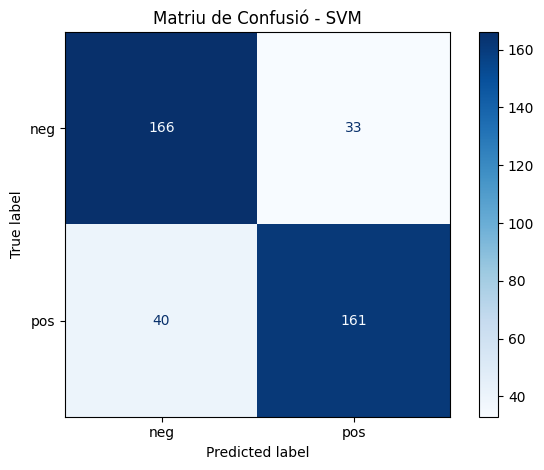


CORBA ROC-AUC:
  AUC Score: 0.8879


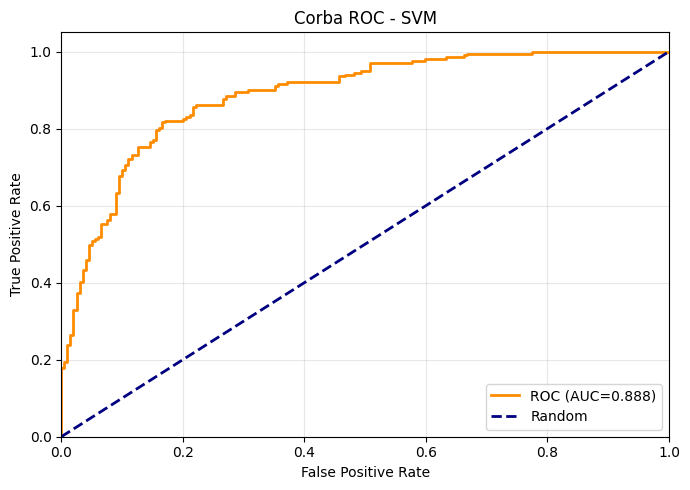


ANÀLISI D'ERRORS:
  Nombre d'errors: 73 / 400
  Taxa d'errors: 0.1825 (18.25%)

  EXEMPLES MAL CLASSIFICATS:

  Error 1:
    Real: neg → Predicció: pos
    Text: 'caliber killer struck starring john leguizamo mira sorvino adrian brody jennifer...'

  Error 2:
    Real: pos → Predicció: neg
    Text: 'plot human space astronaut accidentally fall upon planet ruled ape taken prisone...'

  Error 3:
    Real: neg → Predicció: pos
    Text: 'porter stoddard warren beatty successful architect married successful fabric des...'

  Error 4:
    Real: neg → Predicció: pos
    Text: 'following review encompasses two version dune dune theatrical version runtime mi...'

  Error 5:
    Real: neg → Predicció: pos
    Text: 'steve martin one funniest men alive take true statement disappointment film equa...'

  Error 6:
    Real: pos → Predicció: neg
    Text: 'ever perused college comedy diary another year life nerd never run cheap plug kn...'

  Error 7:
    Real: pos → Predicció: neg
    Text: 'in

<Figure size 700x500 with 0 Axes>

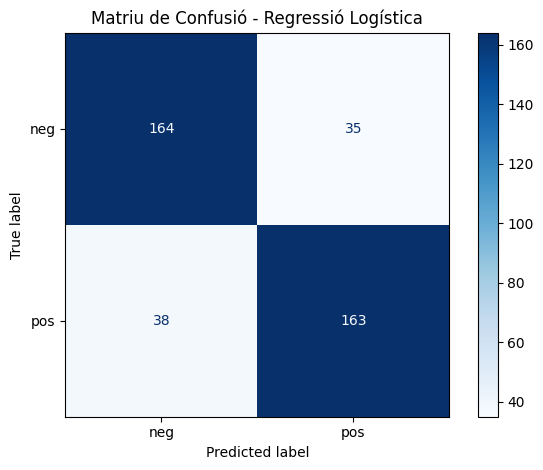


CORBA ROC-AUC:
  AUC Score: 0.8936


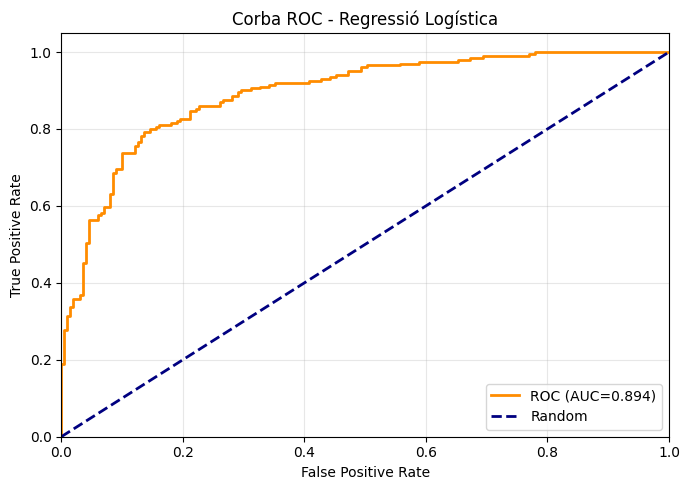


ANÀLISI D'ERRORS:
  Nombre d'errors: 73 / 400
  Taxa d'errors: 0.1825 (18.25%)

  EXEMPLES MAL CLASSIFICATS:

  Error 1:
    Real: neg → Predicció: pos
    Text: 'caliber killer struck starring john leguizamo mira sorvino adrian brody jennifer...'

  Error 2:
    Real: pos → Predicció: neg
    Text: 'plot human space astronaut accidentally fall upon planet ruled ape taken prisone...'

  Error 3:
    Real: neg → Predicció: pos
    Text: 'name jack carter want know say brooding anti hero sylvester stallone take advice...'

  Error 4:
    Real: neg → Predicció: pos
    Text: 'porter stoddard warren beatty successful architect married successful fabric des...'

  Error 5:
    Real: neg → Predicció: pos
    Text: 'following review encompasses two version dune dune theatrical version runtime mi...'

  Error 6:
    Real: neg → Predicció: pos
    Text: 'steve martin one funniest men alive take true statement disappointment film equa...'

  Error 7:
    Real: pos → Predicció: neg
    Text: 'ev

<Figure size 700x500 with 0 Axes>

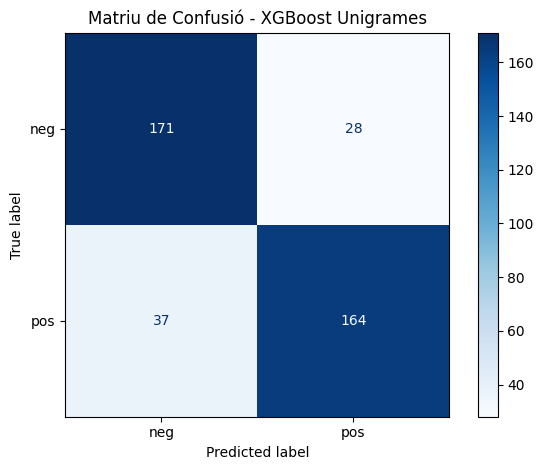


CORBA ROC-AUC:
  AUC Score: 0.9037


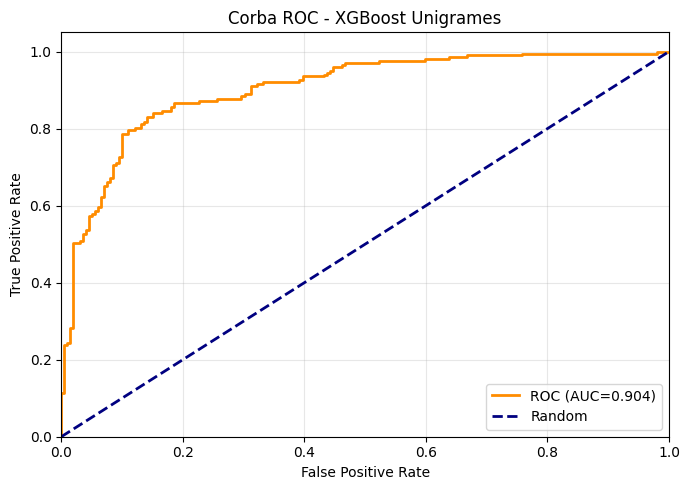


ANÀLISI D'ERRORS:
  Nombre d'errors: 65 / 400
  Taxa d'errors: 0.1625 (16.25%)

  EXEMPLES MAL CLASSIFICATS:

  Error 1:
    Real: pos → Predicció: neg
    Text: 'company men made splash sundance film festival year plagued brother mcmullen sty...'

  Error 2:
    Real: neg → Predicció: pos
    Text: 'year captain leo davidson mark wahlberg boogie night training chimp pericles pil...'

  Error 3:
    Real: neg → Predicció: pos
    Text: 'following review encompasses two version dune dune theatrical version runtime mi...'

  Error 4:
    Real: neg → Predicció: pos
    Text: 'steve martin one funniest men alive take true statement disappointment film equa...'

  Error 5:
    Real: pos → Predicció: neg
    Text: 'heard many critic describe return old fashioned hollywood romance kept asking go...'

  Error 6:
    Real: pos → Predicció: neg
    Text: 'inseparable team sgt martin riggs mel gibson sgt roger murtaugh danny glover let...'

  Error 7:
    Real: neg → Predicció: pos
    Text: 'ad

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
import matplotlib.pyplot as plt
import numpy as np

print("COMPARACIÓ FINAL: SVM vs REGRESSIÓ LOGÍSTICA vs XGBOOST")

# 1. DEFINIR I ENTRENAR MODELS FINALS

# SVM FINAL
print("\n1. Entrenant model final de SVM (C=10, kernel=rbf, gamma=auto, max_features=12000)...")
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

final_svm = Pipeline([
    ("vect", CountVectorizer(max_features=12000)),
    ("svc", SVC(C=10, kernel="rbf", gamma="auto"))
])

final_svm.fit(X_train, y_train)
y_pred_svm = final_svm.predict(X_test)

# XGBoost UNIGRAMES FINAL
print("2. Entrenant model final de XGBoost Unigrames (max_features=12000, n_est=300, depth=3, lr=0.05)...")
from xgboost import XGBClassifier

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

xgb_unigram = Pipeline([
    ("vect", CountVectorizer(max_features=12000, ngram_range=(1, 1))),
    ("xgb", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, 
                          eval_metric="logloss", verbosity=0))
])

xgb_unigram.fit(X_train, y_train_enc)
y_pred_unigram_enc = xgb_unigram.predict(X_test)
y_pred_unigram = label_encoder.inverse_transform(y_pred_unigram_enc)

print("3. Entrenant model final de Regressió Logística (max_features=5000, C=0.01, penalty=l2)")


final_rl = Pipeline([
    ("vect", CountVectorizer(max_features=5000)),
    ("logreg", LogisticRegression(C=0.01, penalty="l2", solver="lbfgs", max_iter=3000))
])

final_rl.fit(X_train, y_train)
y_pred_rl = final_rl.predict(X_test)

# 2. DEFINIR MODELS PER A COMPARACIÓ
models = {
    "SVM (RBF, C=10, max_features=12000)": {
        "model": final_svm,
        "predictions": y_pred_svm,
        "requires_encoding": False
    },
    "Regressió Logística (C=0.01, penalty=l2, max_features=5000)": {
        "model": final_rl,
        "predictions": y_pred_rl,
        "requires_encoding": False
    },
    "XGBoost Unigrames (max_features=12000, n_est=300, depth=3, lr=0.05)": {
        "model": xgb_unigram,
        "predictions": y_pred_unigram,
        "requires_encoding": False
    }
}

y_test_arr = np.array(y_test)
y_test_bin = (y_test_arr == "pos").astype(int)

# 3. CALCULAR I MOSTRAR MÈTRIQUES PER A CADA MODEL
results_summary = []

for model_name, model_info in models.items():
    model = model_info["model"]
    y_pred = model_info["predictions"]
    
    print("\n" + "="*90)
    print(f"MODEL: {model_name}")
    print("="*90)
    
    # Mètriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label="pos", zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label="pos", zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label="pos", zero_division=0)
    
    print(f"\nMÈTRIQUES DE RENDIMENT:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    results_summary.append({
        "Model": model_name.split("(")[0].strip(),
        "Accuracy": f"{accuracy:.4f}",
        "Precision": f"{precision:.4f}",
        "Recall": f"{recall:.4f}",
        "F1-Score": f"{f1:.4f}"
    })
    
    # MATRIU DE CONFUSIÓ
    print(f"\nMATRIU DE CONFUSIÓ:")
    cm = confusion_matrix(y_test, y_pred)
    print(f"  {'':15} Predicció Neg  Predicció Pos")
    print(f"  Real Neg:       {cm[0,0]:6d}         {cm[0,1]:6d}")
    print(f"  Real Pos:       {cm[1,0]:6d}         {cm[1,1]:6d}")
    
    # Gràfic Matriu de Confusió
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"])
    plt.figure(figsize=(7, 5))
    disp.plot(cmap='Blues')
    plt.title(f"Matriu de Confusió - {model_name.split('(')[0].strip()}")
    plt.tight_layout()
    plt.show()
    
    # CORBA ROC-AUC
    print(f"\nCORBA ROC-AUC:")
    try:
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_proba = model.decision_function(X_test) if hasattr(model, 'decision_function') else model.predict(X_test).astype(float)
        
        fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
        roc_auc = auc(fpr, tpr)
        
        print(f"  AUC Score: {roc_auc:.4f}")
        
        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC={roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f"Corba ROC - {model_name.split('(')[0].strip()}")
        plt.legend(loc='lower right')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  Error calculant ROC: {e}")
    
    # ERRORS I EXEMPLES MAL CLASSIFICATS
    print(f"\nANÀLISI D'ERRORS:")
    errors_mask = y_pred != y_test_arr
    num_errors = np.sum(errors_mask)
    error_rate = num_errors / len(y_test_arr)
    
    print(f"  Nombre d'errors: {num_errors} / {len(y_test_arr)}")
    print(f"  Taxa d'errors: {error_rate:.4f} ({error_rate*100:.2f}%)")
    
    if num_errors > 0:
        print(f"\n  EXEMPLES MAL CLASSIFICATS:")
        error_indices = np.where(errors_mask)[0]
        
        for i, idx in enumerate(error_indices, 1):
            actual = y_test_arr[idx]
            predicted = y_pred[idx]
            text_preview = X_test[idx][:80] + "..." if len(X_test[idx]) > 80 else X_test[idx]
            
            print(f"\n  Error {i}:")
            print(f"    Real: {actual} → Predicció: {predicted}")
            print(f"    Text: '{text_preview}'")

# 4. TAULA RESUM COMPARATIVA
print("\n" + "="*90)
print("TAULA RESUM COMPARATIVA")
print("="*90)

import pandas as pd
df_results = pd.DataFrame(results_summary)
print("\n" + df_results.to_string(index=False))


## Anàlisis SVM

Gràcies a la matriu de confusió podem observar que, a més d'obtenir un bon accuracy, el model no prioritza cap de les dues classes, cosa que és senyal d'un bon aprenentatge equilibrat, malgrat hi hagi alguns FN més que FP. Malgrat això, ha comès alguns errors que, analitzant-los, ens permeten deduir quins són els principals problemes del model a l'hora de classificar.

Pel que fa a la corba ROC, s'obté un AUC de 0.8879, la qual cosa indica que es tracta d'un classificador de bona qualitat.
Quant als errors, se n'han identificat quatre causes principals:

La primera és el pes enganyós de certes paraules. El model associa paraules com "successful", "happy" o "never" a una classe concreta, quan en realitat el seu sentiment depèn del context. Per exemple, a l'error 3, la paraula "successful" apareix dues vegades en una ressenya negativa i fa que el model la classifiqui com a positiva. De manera similar, a l'error 34, la paraula "happy" indueix el model a error en una ressenya positiva, i a l'error 6, "never" fa que una ressenya positiva es classifiqui com a negativa.

La segona causa són la ironia i el sarcasme. El model no és capaç d'entendre el context global d'una frase. A l'error 14, la ressenya descriu "battlefield earth" com el pitjor film de l'any, però paraules com "guarantee" fan que el model la classifiqui com a positiva. De manera semblant, a l'error 21, el crític valora positivament "evil dead ii" precisament pels seus defectes, "bad movie", "terrible acting", cosa que el model és incapaç de capturar.

La tercera causa és el vocabulari temàtic enganyós. Certes paraules estan tan associades a un sentiment concret dins del corpus que el model les utilitza com a indicadors independentment del context. Als errors 29 i 49, la paraula "Disney" apareix en ressenyes negatives, però com que en el corpus majoritàriament apareix en ressenyes positives, el model la classifica erròniament com a positiva.

La quarta causa són les ressenyes amb estructura mixta. Algunes ressenyes comencen elogiant aspectes de la pel·lícula i acaben criticant-la, o a l'inrevés. A l'error 5, la ressenya comença amb "steve martin one funniest men alive" però conclou que la pel·lícula és una decepció. El model es queda amb el sentiment predominant de les primeres paraules i no és capaç de capturar el gir negatiu final.

Malgrat això compta amb un Accuracy de 0.8175.


## Anàlisis Regressió Logística

Pel que fa a la Regressió Logística, la matriu de confusió mostra una diferència molt petita entre els falsos positius i els falsos negatius, cosa que indica que el model és encara més equilibrat que el SVM i no tendeix cap a cap classe majoritària. Quant a la corba ROC, s'obté un AUC de 0.8936, lleugerament superior al del SVM, la qual cosa suggereix una millor capacitat d'aprenentatge de patrons. L'accuracy assolida és de 0.8175, amb resultats també en el rang de 0.8-0.9 per a la resta de mètriques com el F1-score i el recall. A continuació s'analitzen alguns dels errors comesos per entendre quines situacions generen una classificació incorrecta.

En el cas de la Regressió Logística, els errors comesos segueixen una línia semblant als del model anterior, encara que amb algunes particularitats pròpies.

Un primer bloc d'errors s'explica per la càrrega semàntica individual de certes paraules. El model aprèn a associar determinades paraules a una classe concreta, però aquest aprenentatge falla quan apareixen en un context diferent. A l'error 65, el terme "successful" apareix en una ressenya negativa sobre Woody Allen i confon el model. De manera similar, a l'error 63, la mateixa paraula torna a aparèixer en una ressenya clarament negativa, on es descriu una pel·lícula com a candidata al pitjor film de l'any.

Un segon bloc d'errors prové de la incapacitat del model per detectar ironia i sarcasme. A l'error 66, la ressenya descriu "Armageddon" com una pel·lícula que "symbolizes everything wrong modern filmmaking", però altres paraules del text fan decantar el model cap a la classe negativa quan en realitat és positiva. L'error 52 és també representatiu: el crític descriu un blockbuster amb "bad script" i malgrat això la ressenya és positiva, ja que valora favorablement altres aspectes de la pel·lícula.

Un tercer bloc respon al biaix introduït per noms propis i marques. Als errors 53 i 58, la presència de termes associats a gèneres o estudis concrets porta el model a classificar incorrectament. A l'error 72, el nom "Terrence Malick" actua com a indicador positiu espuri en una ressenya negativa, atès que aquest director apareix habitualment lligat a valoracions positives dins el corpus.

Finalment, un quart bloc d'errors correspon a ressenyes amb un arc narratiu contradictori. A l'error 57, la ressenya comença descrivint una experiència prèvia positiva abans de girar cap a una valoració negativa de la pel·lícula en qüestió. A l'error 70, el crític reconeix aspectes positius al principi del text abans de concloure amb una valoració negativa, cosa que fa que el model es quedi amb el sentiment dominant de les primeres paraules i no processi el canvi de to posterior.

Aquests patrons coincideixen en gran mesura amb els observats al SVM.
  

## Anàlisis XGBoost


El XGBoost és el model que ofereix els millors resultats globals. La matriu de confusió reflecteix el nombre més baix de classificacions incorrectes dels tres models, i la corba ROC assoleix el valor d'AUC més alt (0.9037). Les mètriques obtingudes sobre el conjunt de test són les següents: un accuracy de 0.8375, una precisió de 0.8542, un recall de 0.8159 i un F1-score de 0.8346. Cal remarcar que el recall és lleugerament inferior a la precisió, tot i que la diferència és poc rellevant i no compromet la qualitat del model.

Malgrat el bon rendiment general, el model comet errors que es poden agrupar en diverses categories.

La primera categoria agrupa els errors causats pel pes de determinades paraules fora de context. El model ha après que certes expressions estan lligades a un sentiment concret, però aquest aprenentatge es trenca quan les mateixes paraules apareixen en un context diferent. A l'error 4, la frase "steve martin one funniest men alive" provoca que el model prevegi un sentiment positiu quan la ressenya és en realitat una crítica negativa a la pel·lícula. A l'error 54, el qualificatiu "successful" aplicat a Woody Allen orienta erròniament el model cap a la classe positiva, malgrat que la ressenya qüestiona la seva trajectòria recent.

La segona categoria recull els errors vinculats a la detecció d'ironia i sarcasme. A l'error 15, expressions com "bad movie", "terrible acting" i "pointless violence" haurien d'indicar un sentiment clarament negatiu, però la ressenya és positiva perquè l'autor considera "Evil Dead II" una obra de culte que val la pena precisament pels seus excessos. A l'error 55, la ressenya critica "Armageddon" com a símbol dels mals del cinema contemporani, però el model no és capaç de llegir el to irònic i la classifica incorrectament.

La tercera categoria engloba els errors provocats pel valor dels noms propis. Tant als errors 31 i 37, la paraula "Disney" apareix en ressenyes negatives, però com que al corpus aquesta marca sol anar acompanyada de valoracions positives, el model la interpreta com un senyal favorable. A l'error 61, el nom "Terrence Malick" genera el mateix efecte: el model associa automàticament aquest director a crítiques positives i falla quan la ressenya és negativa. O el biaix per referències a la cultura popular. A l'error 63, mencions a les Spice Girls i a productes d'entreteniment massius confonen el model. A l'error 2, referències a Mark Wahlberg i a "Boogie Nights", figures amb a un cert prestigi, fan inclinar la predicció cap al sentiment positiu en una ressenya que en realitat és negativa.

La quarta categoria recull els errors deguts a ressenyes contradictories. A l'error 22, el crític comença reconeixent el potencial de la pel·lícula i només al final revela que el resultat és decebedor. A l'error 46, la ressenya s'inicia recordant una experiència cinematogràfica prèvia agradable, però acaba criticant durament la pel·lícula analitzada. En ambdós casos, el model es queda ancorat en el to positiu de l'inici i no detecta el gir negatiu posterior.


En definitiva, tot i que el XGBoost supera els altres dos models en totes les mètriques, els tipus d'errors que comet són essencialment els mateixos. Això confirma que el sostre de rendiment d'aquests models no ve determinat per l'algorisme escollit, sinó per la manera com es representa el text: el CountVectorizer tracta cada paraula com una unitat independent, sense tenir en compte l'ordre, el context ni les relacions semàntiques entre paraules.

## Conclusions 

Després d'analitzar els tres models i comprovar que els seus errors de classificació responen a patrons similars, s'ha decidit escollir el XGBoost com a model final, ja que és el que obté els millors resultats en totes les mètriques avaluades.

## MODEL FINAL

Un cop escollit el model final, i havent identificat algunes de les causes dels errors, s'analitzarà si l'ús de bigrames en lloc d'unigrames pot millorar la capacitat predictiva del model, ja que permeten capturar relacions més complexes entre paraules, com ara "don't like". D'aquesta manera es podrà determinar si aquest canvi és suficient per millorar el rendiment o si calen modificacions més profundes.

COMPARACIÓ: XGBoost Unigrames vs XGBoost Bigrames

MODEL: XGBoost Unigrames

MÈTRIQUES DE RENDIMENT:
  Accuracy:  0.8375
  Precision: 0.8542
  Recall:    0.8159
  F1-Score:  0.8346

MATRIU DE CONFUSIÓ:
                  Predicció Neg  Predicció Pos
  Real Neg:          171             28
  Real Pos:           37            164


<Figure size 700x500 with 0 Axes>

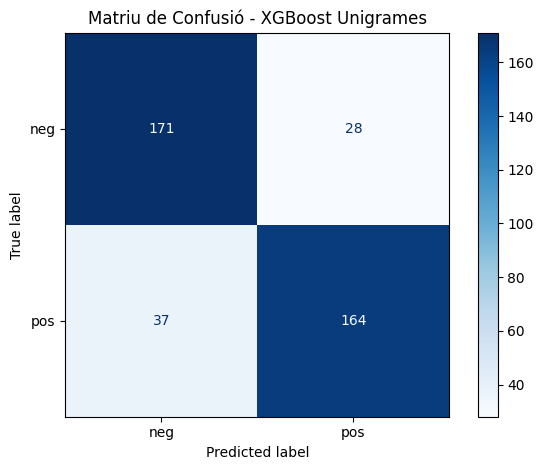


ANÀLISI D'ERRORS:
  Nombre d'errors: 65 / 400
  Taxa d'errors: 0.1625 (16.25%)

  EXEMPLES MAL CLASSIFICATS:

  Error 0:
    Real: pos → Predicció: neg
    Text: 'company men made splash sundance film festival year plagued brother mcmullen style earnestly shallow...'

  Error 1:
    Real: neg → Predicció: pos
    Text: 'year captain leo davidson mark wahlberg boogie night training chimp pericles pilot pod usaf oberon s...'

  Error 2:
    Real: neg → Predicció: pos
    Text: 'following review encompasses two version dune dune theatrical version runtime minute capsule review ...'

  Error 3:
    Real: neg → Predicció: pos
    Text: 'steve martin one funniest men alive take true statement disappointment film equal mine martin hilari...'

  Error 4:
    Real: pos → Predicció: neg
    Text: 'heard many critic describe return old fashioned hollywood romance kept asking going movie exactly ol...'

  Error 5:
    Real: pos → Predicció: neg
    Text: 'inseparable team sgt martin riggs mel gib

<Figure size 700x500 with 0 Axes>

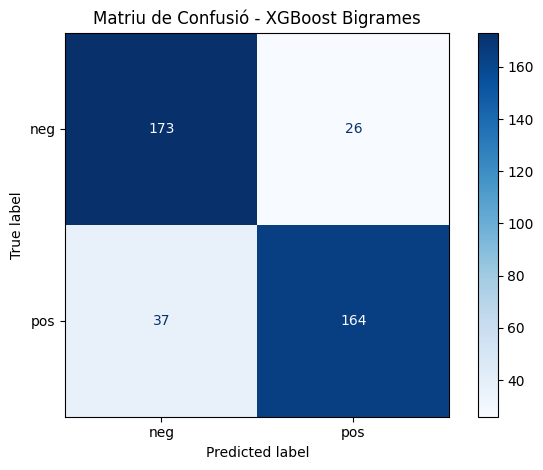


ANÀLISI D'ERRORS:
  Nombre d'errors: 63 / 400
  Taxa d'errors: 0.1575 (15.75%)

  EXEMPLES MAL CLASSIFICATS:

  Error 0:
    Real: neg → Predicció: pos
    Text: 'year captain leo davidson mark wahlberg boogie night training chimp pericles pilot pod usaf oberon s...'

  Error 1:
    Real: neg → Predicció: pos
    Text: 'following review encompasses two version dune dune theatrical version runtime minute capsule review ...'

  Error 2:
    Real: pos → Predicció: neg
    Text: 'vampire lore legend always popular fantasy element substantiated not sheer number movie subject also...'

  Error 3:
    Real: neg → Predicció: pos
    Text: 'steve martin one funniest men alive take true statement disappointment film equal mine martin hilari...'

  Error 4:
    Real: pos → Predicció: neg
    Text: 'heard many critic describe return old fashioned hollywood romance kept asking going movie exactly ol...'

  Error 5:
    Real: pos → Predicció: neg
    Text: 'inseparable team sgt martin riggs mel gib

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

print("="*90)
print("COMPARACIÓ: XGBoost Unigrames vs XGBoost Bigrames")

# 1. ENTRENAR MODEL FINAL DE XGBOOST AMB BIGRAMES

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

xgb_bigram = Pipeline([
    ("vect", CountVectorizer(max_features=12000, ngram_range=(1, 2))),
    ("xgb", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, 
                          eval_metric="logloss", verbosity=0))
])

xgb_bigram.fit(X_train, y_train_enc)
y_pred_bigram_enc = xgb_bigram.predict(X_test)
y_pred_bigram = label_encoder.inverse_transform(y_pred_bigram_enc)

# 2. COMPARACIÓ DELS DOS MODELS
y_test_arr = np.array(y_test)

models_xgb = {
    "XGBoost Unigrames": {
        "model": xgb_unigram,
        "predictions": y_pred_unigram
    },
    "XGBoost Bigrames": {
        "model": xgb_bigram,
        "predictions": y_pred_bigram
    }
}

results = []

for model_name, model_info in models_xgb.items():
    model = model_info["model"]
    y_pred = model_info["predictions"]
    
    print("\n" + "="*90)
    print(f"MODEL: {model_name}")
    print("="*90)
    
    # MÈTRIQUES
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label="pos", zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label="pos", zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label="pos", zero_division=0)
    
    print(f"\nMÈTRIQUES DE RENDIMENT:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    results.append({
        "Model": model_name,
        "Accuracy": f"{accuracy:.4f}",
        "Precision": f"{precision:.4f}",
        "Recall": f"{recall:.4f}",
        "F1-Score": f"{f1:.4f}"
    })
    
    # MATRIU DE CONFUSIÓ
    print(f"\nMATRIU DE CONFUSIÓ:")
    cm = confusion_matrix(y_test, y_pred)
    print(f"  {'':15} Predicció Neg  Predicció Pos")
    print(f"  Real Neg:       {cm[0,0]:6d}         {cm[0,1]:6d}")
    print(f"  Real Pos:       {cm[1,0]:6d}         {cm[1,1]:6d}")
    
    # GRÀFIC MATRIU DE CONFUSIÓ
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"])
    plt.figure(figsize=(7, 5))
    disp.plot(cmap='Blues')
    plt.title(f"Matriu de Confusió - {model_name}")
    plt.tight_layout()
    plt.show()
    
    # ERRORS I EXEMPLES MAL CLASSIFICATS
    print(f"\nANÀLISI D'ERRORS:")
    errors_mask = y_pred != y_test_arr
    num_errors = np.sum(errors_mask)
    error_rate = num_errors / len(y_test_arr)
    
    print(f"  Nombre d'errors: {num_errors} / {len(y_test_arr)}")
    print(f"  Taxa d'errors: {error_rate:.4f} ({error_rate*100:.2f}%)")
    
    if num_errors > 0:
        print(f"\n  EXEMPLES MAL CLASSIFICATS:")
        error_indices = np.where(errors_mask)[0]
        
        for i, idx in enumerate(error_indices):
            actual = y_test_arr[idx]
            predicted = y_pred[idx]
            text_preview = X_test[idx][:100] + "..." if len(X_test[idx]) > 100 else X_test[idx]
            
            print(f"\n  Error {i}:")
            print(f"    Real: {actual} → Predicció: {predicted}")
            print(f"    Text: '{text_preview}'")

# 3. TAULA RESUM COMPARATIVA
print("\n" + "="*90)
print("TAULA RESUM COMPARATIVA")
print("="*90)

df_xgb = pd.DataFrame(results)
print("\n" + df_xgb.to_string(index=False))

print("\n" + "="*90)
print("CONCLUSIÓ")
print("="*90)

f1_unigram = float(results[0]["F1-Score"])
f1_bigram = float(results[1]["F1-Score"])



## Conclusió Model Final

Comparant els dos models, el que utilitza bigrames obté millors resultats tant en la matriu de confusió com en l'accuracy i, per tant, en la taxa d'errors. Analitzant els errors de tots dos, es poden extreure les conclusions següents sobre l'aportació dels bigrames respecte als unigrames.

El model amb unigrames comet 65 errors, mentre que el model amb bigrames en comet 63. La reducció és molt petita, cosa que indica que els bigrames aporten una millora marginal però no substancial.

Pel que fa als errors que els bigrames han aconseguit resoldre, s'observa que alguns casos que els unigrames classificaven incorrectament desapareixen amb l'ús de parelles de paraules. Per exemple, l'error 14 dels unigrames "evil dead ii bad movie full terrible acting pointless violence"  es classifica correctament amb bigrames, probablement perquè combinacions com "bad movie" o "terrible acting" aporten més context que les paraules aïllades. De manera similar, l'error 43 "bowfinger good movie making bad one" també es resol, ja que parelles com "good movie" i "bad one" ajuden a calibrar millor el sentiment global.

Malgrat això, la gran majoria d'errors es repeteixen en els dos models. Casos com "steve martin one funniest men alive" (error 3 en tots dos), "Woody Allen successful" (errors 53 i 51), "Terrence Malick" (errors 60 i 59) o les Spice Girls (errors 62 i 61) apareixen en ambdues llistes sense variació. Això posa de manifest que els bigrames no resolen els problemes estructurals del model: el biaix introduït per noms propis, la ironia i les ressenyes amb un arc narratiu contradictori continuen sent fonts d'error independentment del tipus de n-grama utilitzat.

A més, els bigrames introdueixen alguns errors nous que els unigrames no cometien, com ara l'error 2 "vampire lore legend always popular fantasy" , l'error 24 "rushmore"  o l'error 44 "razor blade smile". Això suggereix que en determinats casos els bigrames sobreajusten el model a combinacions de paraules molt concretes que no generalitzen bé a exemples nous.

En conclusió, tot i que els bigrames aporten una millora lleugera, no resolen les limitacions fonamentals del model. Per obtenir un increment significatiu del rendiment caldria un enfocament diferent, basat en representacions semàntiques més riques i robustes que tinguin en compte el context global de cada ressenya.

# Pràctica 2.b — Detecció d'Opinions No Supervisada

A diferència de l'apartat 2.a, on s'han entrenat classificadors supervisats amb etiquetes, en aquesta part s'implementa un mètode no supervisat basat en el léxic SentiWordNet. L'objectiu és determinar si una ressenya és positiva o negativa sense cap procés d'entrenament previ, únicament a partir de la polaritat semàntica de les paraules individuals.

L'avantatge principal d'aquest enfocament és que no requereix dades etiquetades. La contrapartida és que no captura dependències contextuals ni estructures sintàctiques complexes, i la seva precisió pot ser inferior a la dels mètodes supervisats.

## Implementació

### Preprocessament

S'ha utilitzat el mateix conjunt de test (X_test, y_test) de la pràctica 2.a per garantir que els resultats siguin directament comparables. El mètode aplica internament tokenització amb word_tokenize i etiquetatge morfosintàctic (POS tagging) amb averaged_perceptron_tagger, necessaris per identificar les categories gramaticals de cada paraula i aplicar l'algorisme de Lesk.

### Desambiguació de sentits: algorisme de Lesk

Per a cada paraula del text, s'utilitza l'algorisme de Lesk (implementat a nltk.wsd.lesk) per seleccionar el synset de WordNet que millor s'ajusta al context. El synset obtingut es consulta a SentiWordNet, que assigna tres valors a cada synset: pos_score, neg_score i obj_score. La puntuació de sentiment d'una paraula es calcula com:
    
    score = pos_score − neg_score

La puntuació final d'un text és la suma de les puntuacions de totes les paraules seleccionades. Si la suma és positiva, es classifica com a pos; si és negativa o zero, com a "neg".

### Estratègies quan Lesk no troba synset

En molts casos, Lesk no aconsegueix desambiguar una paraula (synset None) o el synset trobat no existeix a SentiWordNet. S'han implementat tres estratègies per gestionar aquests casos:

- Ignorar (ignore): La paraula no contribueix a la puntuació final. És l'estratègia més conservadora.
- Primer (first): Si Lesk falla, s'utilitza el primer synset que retorna WordNet per a aquella paraula i categoria gramatical. Assumeix que el sentit més freqüent és el més probable.
- Mitjana (average): Es calcula la mitjana de les puntuacions de tots els synsets disponibles per a la paraula. Incorpora més informació però pot introduir soroll.



In [132]:
import re
import numpy as np
import nltk

from nltk.corpus import stopwords, wordnet as wn, sentiwordnet as swn
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.wsd import lesk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc, classification_report
)

In [133]:

# Descàrregues necessàries (només la primera vegada)
for recurs in ["punkt", "stopwords", "wordnet", "averaged_perceptron_tagger",
               "sentiwordnet", "punkt_tab"]:
    nltk.download(recurs, quiet=True)


In [135]:
def penn_to_wn(tag: str):
    """Converteix etiquetes Penn Treebank a etiquetes POS de WordNet."""
    if tag.startswith("J"): return wn.ADJ
    if tag.startswith("V"): return wn.VERB
    if tag.startswith("N"): return wn.NOUN
    if tag.startswith("R"): return wn.ADV
    return None

WN_TAG_MAP = {
    wn.ADJ:  "ADJ",
    wn.VERB: "VERB",
    wn.NOUN: "NOUN",
    wn.ADV:  "ADV"
}

LABEL_TO_WN = {v: k for k, v in WN_TAG_MAP.items()}

In [136]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def clean_text_string(text: str) -> str:
    """Neteja bàsica sense tractament de negació."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if (t not in stop_words and len(t) > 1) or t in ("not", "no", "don't")
    ]
    return " ".join(tokens)

In [143]:
from nltk.corpus import movie_reviews as mr

documents_clean = []
labels_all      = []

for categoria in mr.categories():
    for fileid in mr.fileids(categoria):
        raw_text   = mr.raw(fileid)
        clean      = clean_text_string(raw_text)

        if clean:
            documents_clean.append(clean)
            labels_all.append(categoria)

# Un sol split — mateix random_state garanteix comparació justa entre models
X_train_ns, X_test_ns, \
y_train, y_test = train_test_split(
    documents_clean, labels_all,
    test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)} mostres | Test: {len(X_test)} mostres")

Train: 1600 mostres | Test: 400 mostres


In [145]:
from nltk import pos_tag, word_tokenize

def preprocess_with_pos_tokens(texts):
    """Preprocesa lista de textos: retorna listas de tokens + POS tags"""
    tokens_list = []
    pos_tags_list = []
    
    for text in texts:
        tokens = word_tokenize(text)
        pos_tags = pos_tag(tokens)
        tokens_list.append(tokens)
        pos_tags_list.append(pos_tags)
    
    return tokens_list, pos_tags_list

# Ahora puedes procesar listas
X_test_tokens, X_test_pos_tags = preprocess_with_pos_tokens(X_test_ns)
X_train_tokens, X_train_pos_tags = preprocess_with_pos_tokens(X_train_ns)

In [146]:
from nltk.corpus import sentiwordnet as swn
from nltk.corpus import wordnet as wn
import nltk
from nltk.wsd import lesk

# Descargar si no tienes
nltk.download('sentiwordnet')
nltk.download('averaged_perceptron_tagger')

def penn_to_wn(tag):
    """Convierte Penn Treebank tags a WordNet POS tags"""
    if tag.startswith('J'):
        return wn.ADJ
    if tag.startswith('V'):
        return wn.VERB
    if tag.startswith('N'):
        return wn.NOUN
    if tag.startswith('R'):
        return wn.ADV
    return None


def sentiment_score_unsupervised_wsd(pos_tags, tokens, pos_categories=['ADJ'], strategy='ignore'):
    """
    Calcula sentiment score CON desambiguación (Lesk)
    
    strategy:
        "ignore"  -> ignorar la paraula (no contribuye al score)
        "first"   -> utilitzar el primer synset de WordNet
        "average" -> utilitzar la mitjana dels synsets disponibles
    """
    
    total_score = 0
    synsets_found = 0
    synsets_not_found = 0
    
    for word, tag in pos_tags:
        wn_tag = penn_to_wn(tag)
        pos_map = {wn.ADJ: 'ADJ', wn.VERB: 'VERB', 
                   wn.NOUN: 'NOUN', wn.ADV: 'ADV'}
        
        if wn_tag is None or pos_map.get(wn_tag) not in pos_categories:
            continue
        
        # Usar Lesk para desambiguar
        synset_lesk = lesk(tokens, word, pos=wn_tag)
        
        if strategy == "ignore":
            # ESTRATEGIA 1: IGNORE
            # Solo usa el synset si Lesk lo encuentra
            if not synset_lesk:
                synsets_not_found += 1
                continue
            
            try:
                swn_synset = swn.senti_synset(synset_lesk.name())
                score = swn_synset.pos_score() - swn_synset.neg_score()
                total_score += score
                synsets_found += 1
            except:
                synsets_not_found += 1
        
        elif strategy == "first":
            # ESTRATEGIA 2: FIRST
            # Si Lesk no encuentra, usa el primer synset de WordNet
            synset = synset_lesk if synset_lesk else None
            
            if not synset:
                synsets_list = wn.synsets(word, pos=wn_tag)
                if synsets_list:
                    synset = synsets_list[0]
                else:
                    synsets_not_found += 1
                    continue
            
            try:
                swn_synset = swn.senti_synset(synset.name())
                score = swn_synset.pos_score() - swn_synset.neg_score()
                total_score += score
                synsets_found += 1
            except:
                synsets_not_found += 1
        
        elif strategy == "average":
            # ESTRATEGIA 3: AVERAGE
            # Usa la media de todos los synsets disponibles
            synsets_list = wn.synsets(word, pos=wn_tag)
            
            if not synsets_list:
                synsets_not_found += 1
                continue
            
            scores_list = []
            for synset in synsets_list:
                try:
                    swn_synset = swn.senti_synset(synset.name())
                    score = swn_synset.pos_score() - swn_synset.neg_score()
                    scores_list.append(score)
                except:
                    pass
            
            if scores_list:
                avg_score = np.mean(scores_list)
                total_score += avg_score
                synsets_found += 1
            else:
                synsets_not_found += 1
    
    return total_score, synsets_found, synsets_not_found

[nltk_data] Downloading package sentiwordnet to
[nltk_data]     C:\Users\Natalia\AppData\Roaming\nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Natalia\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


### Categories gramaticals avaluades
S'han dissenyat tres configuracions de categories POS per analitzar quines aporten més informació de sentiment:

In [147]:
pos_configs = {
    "Adj": ['ADJ'],
    "Noms + Adj + Adv": ['NOUN', 'ADJ', 'ADV'],
    "Noms + Adj + Verb + Adv": ['NOUN', 'ADJ', 'VERB', 'ADV']
}

strategies = ["ignore", "first", "average"]

In [149]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, roc_curve, auc)

# APLICAR MÉTODE NO SUPERVISAT AMB TOTES LES CONFIGURACIONS I ESTRATÈGIES
unsupervised_results = {}
y_test_arr = np.array(y_test)

for config_name, pos_list in pos_configs.items():
    unsupervised_results[config_name] = {}
    
    for strategy in strategies:
        print(f"CONFIGURACIÓ: {config_name} | ESTRATEGIA: {strategy}")
        
        # Calcular scores para cada ejemplo
        scores = []
        synsets_stats = {"found": [], "not_found": [], "processed": []}
        
        # Iterar sobre los POS tags y tokens ya preprocessados
        for idx in range(len(X_test_pos_tags)):
            pos_tags = X_test_pos_tags[idx]
            tokens = X_test_tokens[idx]
            
            score, found, not_found = sentiment_score_unsupervised_wsd(
                pos_tags,
                tokens,
                pos_categories=pos_list,
                strategy=strategy
            )
            scores.append(score)
            synsets_stats["found"].append(found)
            synsets_stats["not_found"].append(not_found)
            synsets_stats["processed"].append(found + not_found)
        
        # Convertir scores a predicciones binarias (threshold = 0)
        y_pred_unsup = np.array(["pos" if score > 0 else "neg" for score in scores])
        
        # Calcular métriques
        accuracy = accuracy_score(y_test, y_pred_unsup)
        precision = precision_score(y_test, y_pred_unsup, pos_label="pos", zero_division=0)
        recall = recall_score(y_test, y_pred_unsup, pos_label="pos", zero_division=0)
        f1 = f1_score(y_test, y_pred_unsup, pos_label="pos", zero_division=0)
        cm = confusion_matrix(y_test, y_pred_unsup)
        y_test_bin = (y_test_arr == "pos").astype(int)
        scores_norm = (np.array(scores) - np.min(scores)) / (np.max(scores) - np.min(scores) + 1e-10)
        fpr, tpr, _ = roc_curve(y_test_bin, scores_norm)
        roc_auc = auc(fpr, tpr)
        errors_mask = y_pred_unsup != y_test_arr
        error_indices = np.where(errors_mask)[0]
        
        # Guardar resultados
        unsupervised_results[config_name][strategy] = {
            "pos_list": pos_list,
            "scores": scores,
            "y_pred": y_pred_unsup,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "cm": cm,
            "synsets_stats": synsets_stats,
            "fpr": fpr,
            "tpr": tpr,
            "roc_auc": roc_auc,
            "errors_mask": errors_mask,
            "error_indices": error_indices,
            "num_errors": np.sum(errors_mask)
        }
        
        print(f"Guardat: {config_name} + {strategy}")

CONFIGURACIÓ: Adj | ESTRATEGIA: ignore
Guardat: Adj + ignore
CONFIGURACIÓ: Adj | ESTRATEGIA: first
Guardat: Adj + first
CONFIGURACIÓ: Adj | ESTRATEGIA: average
Guardat: Adj + average
CONFIGURACIÓ: Noms + Adj + Adv | ESTRATEGIA: ignore
Guardat: Noms + Adj + Adv + ignore
CONFIGURACIÓ: Noms + Adj + Adv | ESTRATEGIA: first
Guardat: Noms + Adj + Adv + first
CONFIGURACIÓ: Noms + Adj + Adv | ESTRATEGIA: average
Guardat: Noms + Adj + Adv + average
CONFIGURACIÓ: Noms + Adj + Verb + Adv | ESTRATEGIA: ignore
Guardat: Noms + Adj + Verb + Adv + ignore
CONFIGURACIÓ: Noms + Adj + Verb + Adv | ESTRATEGIA: first
Guardat: Noms + Adj + Verb + Adv + first
CONFIGURACIÓ: Noms + Adj + Verb + Adv | ESTRATEGIA: average
Guardat: Noms + Adj + Verb + Adv + average


## Resultats

A continuació es presenten l'accuracy, precisió, recall, F1-Score i AUC per a les 9 combinacions (3 configuracions × 3 estratègies):

TAULA RESUM: CONFIGURACIONS I ESTRATÈGIES NO SUPERVISADES

           Configuració Estratègia Accuracy Precisió Recall F1-Score    AUC
                    Adj     ignore   0.5900   0.5737 0.7164   0.6372 0.6672
                    Adj      first   0.6525   0.6292 0.7512   0.6848 0.7093
                    Adj    average   0.6550   0.6286 0.7662   0.6906 0.7225
       Noms + Adj + Adv     ignore   0.5900   0.5781 0.6816   0.6256 0.6654
       Noms + Adj + Adv      first   0.6125   0.5983 0.6965   0.6437 0.7038
       Noms + Adj + Adv    average   0.6275   0.6083 0.7264   0.6621 0.7136
Noms + Adj + Verb + Adv     ignore   0.6150   0.5894 0.7711   0.6681 0.6835
Noms + Adj + Verb + Adv      first   0.6300   0.6056 0.7562   0.6726 0.7177
Noms + Adj + Verb + Adv    average   0.6450   0.6089 0.8209   0.6992 0.7281


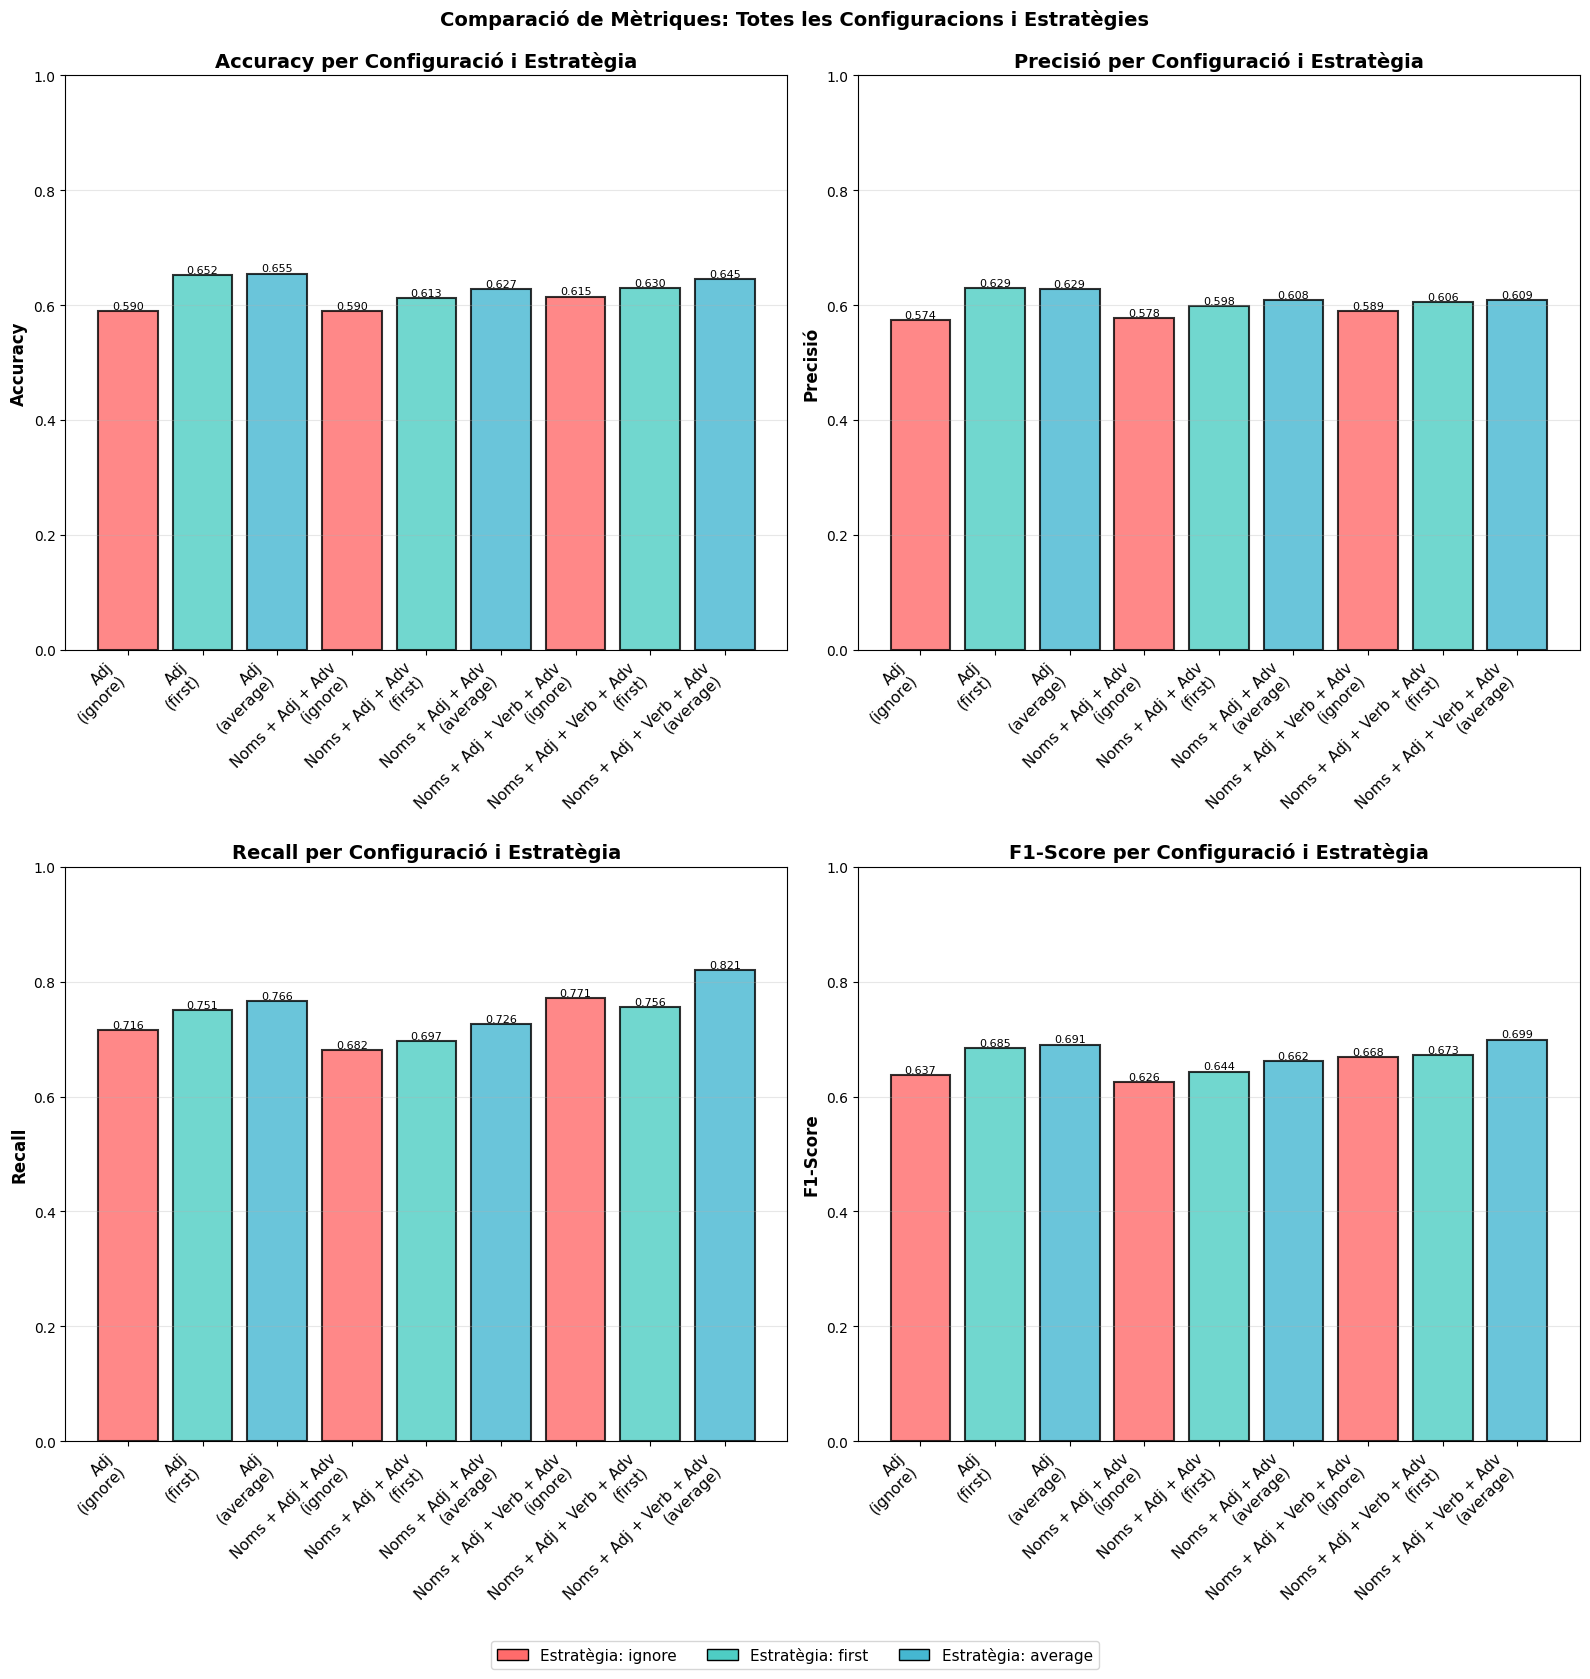

In [151]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TAULA RESUM: CONFIGURACIONS I ESTRATÈGIES NO SUPERVISADES")

data_rows = []

for config_name in pos_configs.keys():
    for strategy in strategies:
        if strategy in unsupervised_results[config_name]:
            result = unsupervised_results[config_name][strategy]
            data_rows.append({
                "Configuració": config_name,
                "Estratègia": strategy,
                "Accuracy": f"{result['accuracy']:.4f}",
                "Precisió": f"{result['precision']:.4f}",
                "Recall": f"{result['recall']:.4f}",
                "F1-Score": f"{result['f1']:.4f}",
                "AUC": f"{result['roc_auc']:.4f}"
            })

df_unsup = pd.DataFrame(data_rows)
print("\n" + df_unsup.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

metrics = ['Accuracy', 'Precisió', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    labels = [f"{row['Configuració']}\n({row['Estratègia']})" for _, row in df_unsup.iterrows()]
    values = [float(row[metric]) for _, row in df_unsup.iterrows()]
    
    colors = []
    for _, row in df_unsup.iterrows():
        if row['Estratègia'] == 'ignore':
            colors.append('#FF6B6B')
        elif row['Estratègia'] == 'first':
            colors.append('#4ECDC4')
        else:
            colors.append('#45B7D1')
    
    bars = ax.bar(range(len(labels)), values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} per Configuració i Estratègia', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', edgecolor='black', label='Estratègia: ignore'),
    Patch(facecolor='#4ECDC4', edgecolor='black', label='Estratègia: first'),
    Patch(facecolor='#45B7D1', edgecolor='black', label='Estratègia: average')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=11)

plt.suptitle('Comparació de Mètriques: Totes les Configuracions i Estratègies', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

### Matrius de confusió

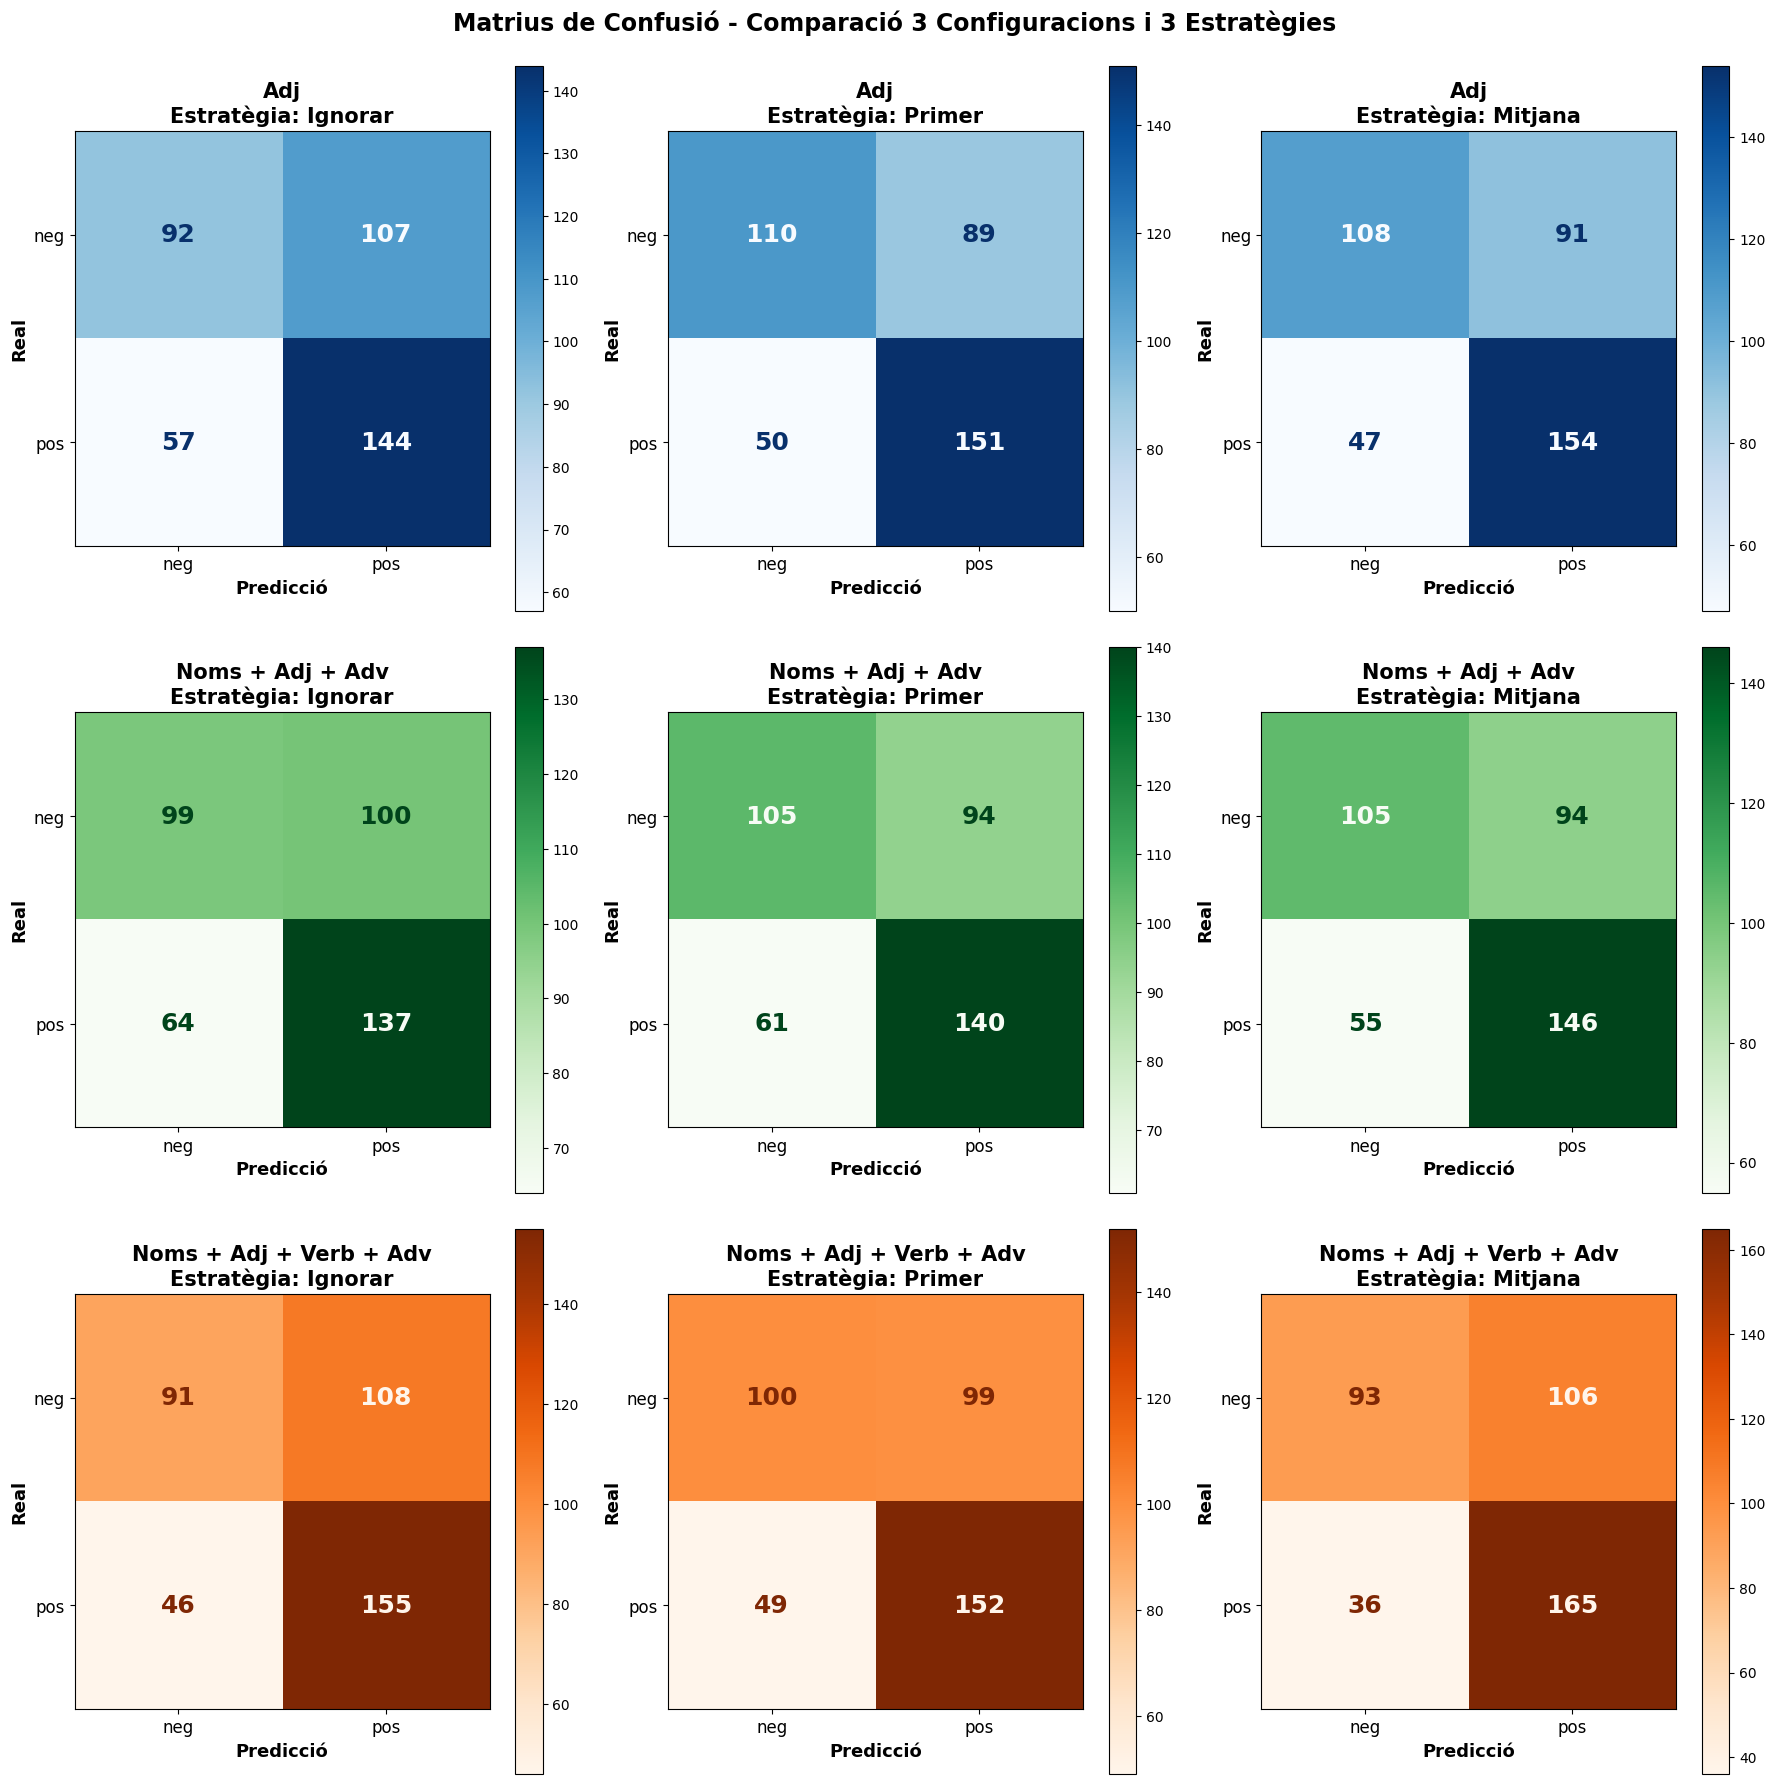

In [152]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Gráfico: 9 Matrices de Confusión en formato 3x3 (3 configuraciones × 3 estrategies)
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

configs = list(unsupervised_results.keys())
strategies = ["ignore", "first", "average"]
colors_list = ['Blues', 'Greens', 'Oranges']
strategy_names = {"ignore": "Ignorar", "first": "Primer", "average": "Mitjana"}

idx = 0
for config_idx, config_name in enumerate(configs):
    for strat_idx, strategy in enumerate(strategies):
        cm = unsupervised_results[config_name][strategy]['cm']
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"])
        disp.plot(cmap=colors_list[config_idx], ax=axes[idx], values_format='d')
        
        # Aumentar tamaño de fuente de los números en la matriz
        for text in axes[idx].texts:
            text.set_fontsize(18)
            text.set_weight('bold')
        
        # Títol amb configuració i estratègia
        title = f"{config_name}\nEstratègia: {strategy_names[strategy]}"
        axes[idx].set_title(title, fontsize=15, fontweight='bold')
        
        # Augmentar tamanys dels eixos
        axes[idx].set_xlabel("Predicció", fontsize=13, fontweight='bold')
        axes[idx].set_ylabel("Real", fontsize=13, fontweight='bold')
        axes[idx].tick_params(axis='both', labelsize=12)
        
        idx += 1

plt.suptitle('Matrius de Confusió - Comparació 3 Configuracions i 3 Estratègies', 
             fontsize=17, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

Les matrius de confusió confirmen un patró consistent: tots els models tendeixen a classificar més exemples com a pos (valors alts al quadrant inferior dret), cosa que es reflecteix en un recall elevat per a la classe positiva però una precisió moderada.

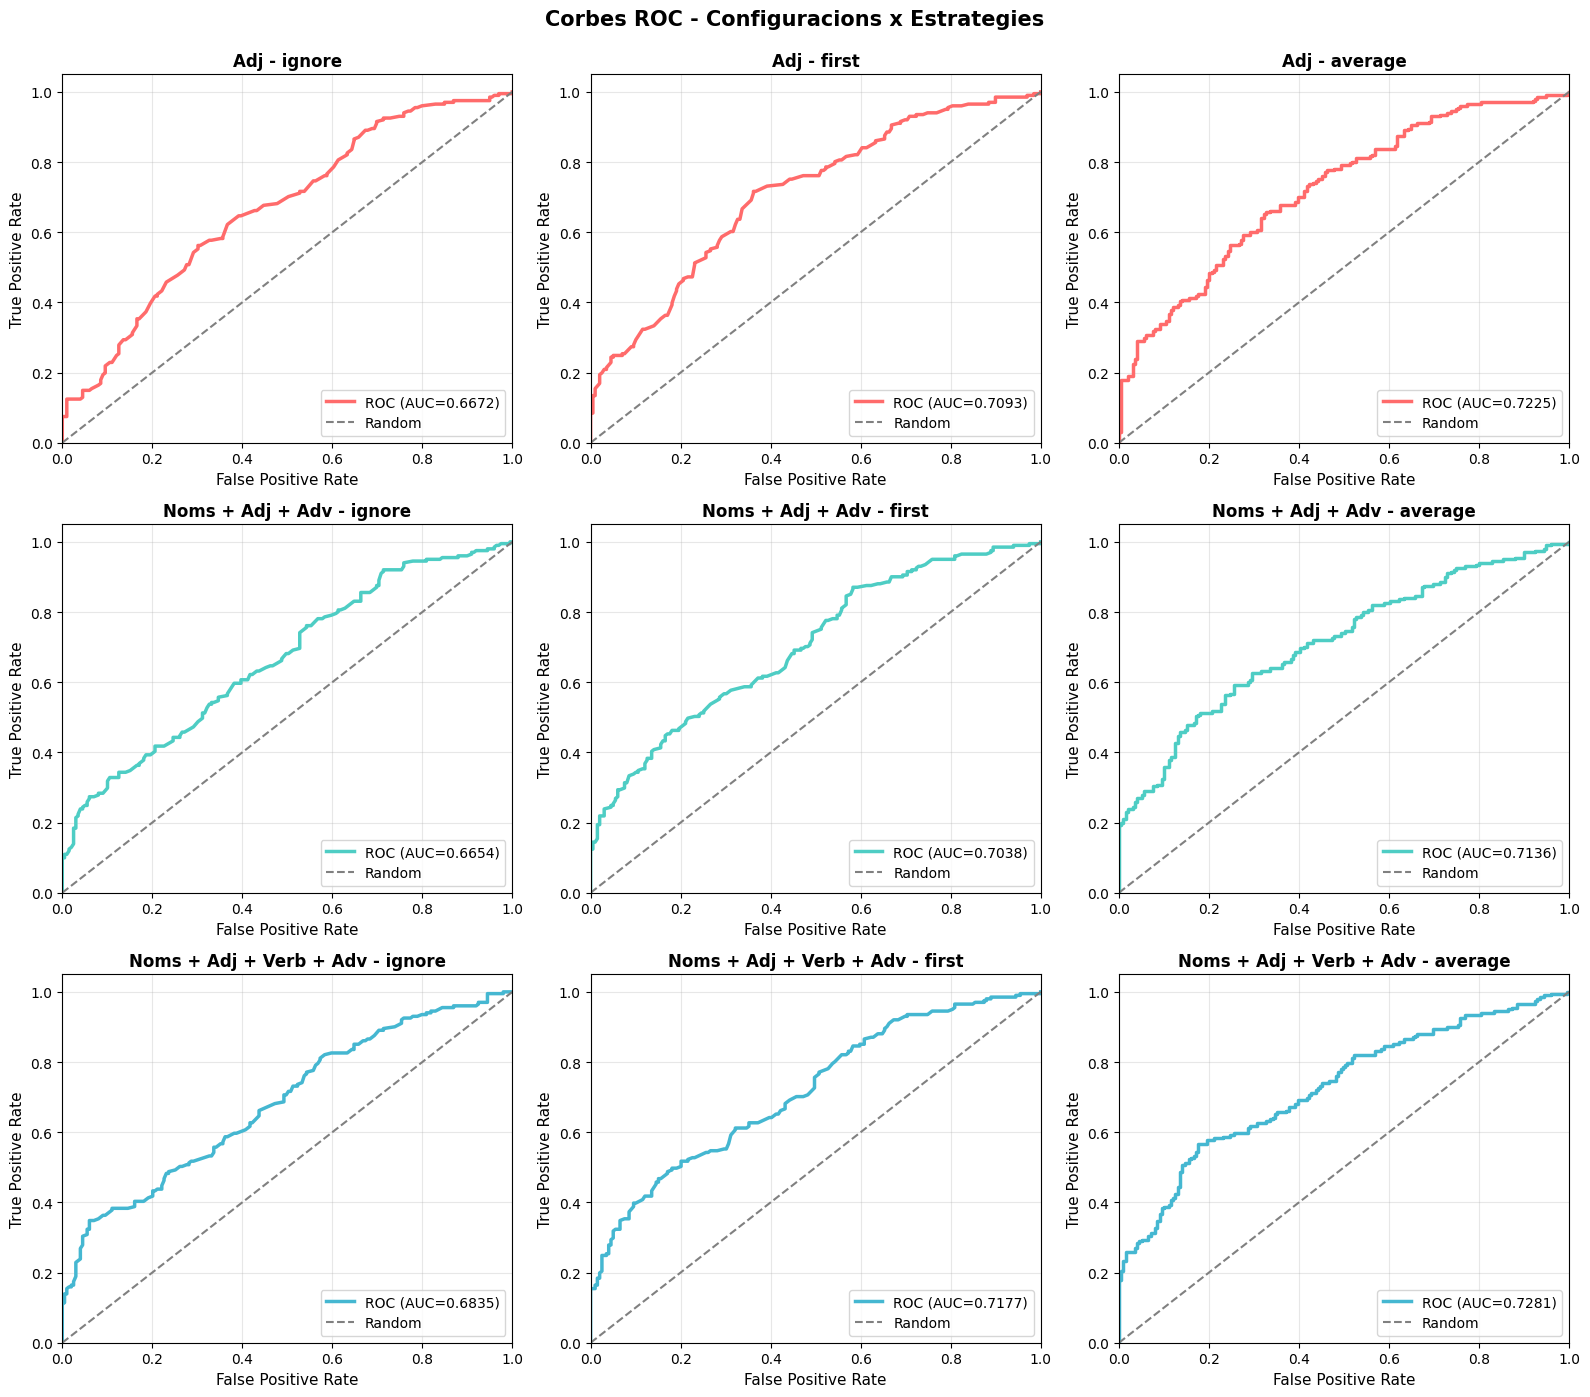

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(unsupervised_results), len(strategies), figsize=(16, 14))

configs = list(unsupervised_results.keys())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for row, config_name in enumerate(configs):
    for col, strategy in enumerate(strategies):
        result = unsupervised_results[config_name][strategy]
        fpr = result['fpr']
        tpr = result['tpr']
        roc_auc = result['roc_auc']
        
        ax = axes[row, col]
        
        ax.plot(fpr, tpr, color=colors[row], lw=2.5, 
                label=f'ROC (AUC={roc_auc:.4f})')
        ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random')
        
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=11)
        ax.set_ylabel('True Positive Rate', fontsize=11)
        ax.set_title(f'{config_name} - {strategy}', fontsize=12, fontweight='bold')
        ax.legend(loc='lower right', fontsize=10)
        ax.grid(alpha=0.3)

plt.suptitle('Corbes ROC - Configuracions x Estrategies', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Anàlisi dels Resultats

Efecte de l'estratègia: L'estratègia Ignorar és la que obté sistemàticament pitjors resultats, ja que descarta moltes paraules útils quan Lesk no aconsegueix desambiguar. Les estratègies Primer i Mitjana milloren l'accuracy entre 3 i 6 punts percentuals respecte a Ignorar en la majoria de configuracions. La Mitjana és lleugerament superior a Primer, especialment en recall i AUC, suggerint que agregar informació de tots els synsets és més robust que triar-ne un arbitràriament.

Efecte de les categories POS: Contràriament al que podria semblar intuïtiu, afegir més categories (noms, verbs, adverbis) als adjectius no millora de manera consistent l'accuracy. De fet, la configuració Adj amb estratègia Primer o Mitjana és la que obté la millor accuracy (0.653–0.655), mentre que les configuracions amb més categories tendeixen a tenir un recall més elevat però una precisió menor. Això suggereix que els adjectius són els portadors principals del sentiment en el léxic, mentre que noms i verbs afegeixen soroll. La configuració Noms + Adj + Verb + Adv amb Mitjana maximitza el recall (0.821) però al cost de més falsos positius.

Biaix cap a la classe positiva: S'observa en totes les configuracions un biaix cap a predir pos. Això és esperable: SentiWordNet cobreix millor el vocabulari positiu que el negatiu en el domini cinematogràfic, i a més molts mots neutres (amb score ≈ 0) acaben sumant lleument cap al positiu.

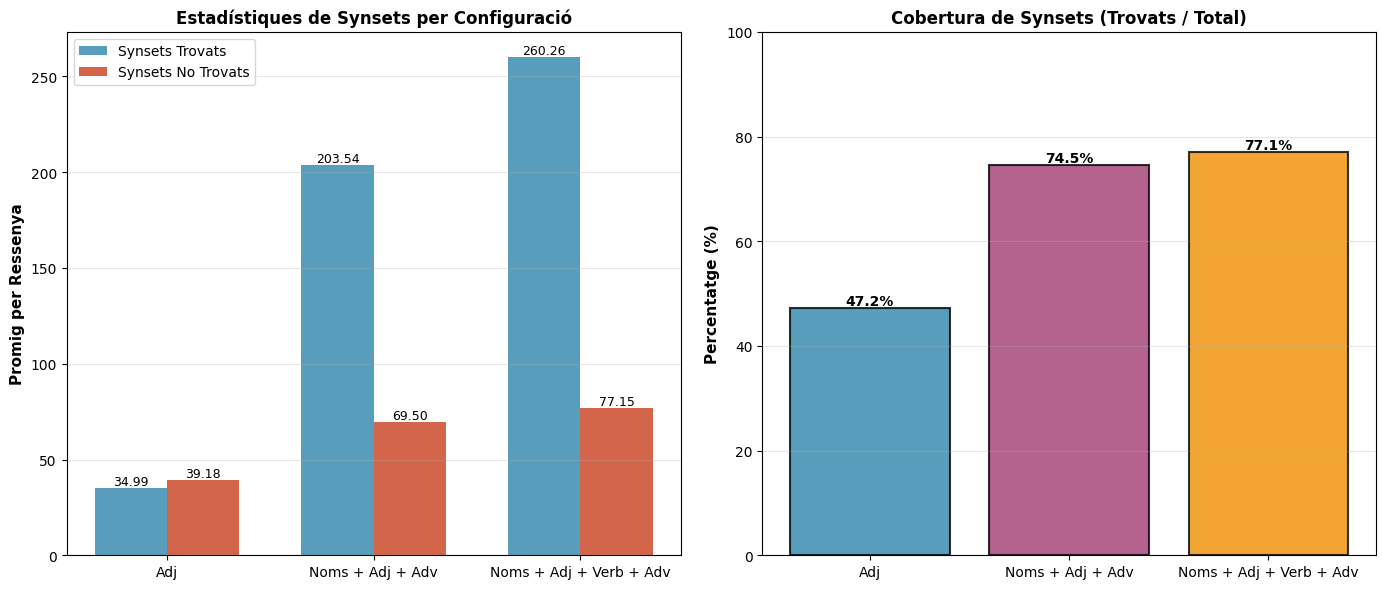


RESUM ESTADÍSTIQUES DE SYNSETS PER CONFIGURACIÓ

           Configuració Synsets Trovats (avg) Synsets No Trovats (avg) Cobertura (%)
                    Adj                 34.99                    39.18         47.2%
       Noms + Adj + Adv                203.54                    69.50         74.5%
Noms + Adj + Verb + Adv                260.26                    77.15         77.1%


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Extraer estadísticas para cada configuración (usar la estrategia "ignore" ya que todas tienen las mismas)
configs = list(unsupervised_results.keys())
avg_found_list = []
avg_not_found_list = []
coverage_pct_list = []

for config_name in configs:
    stats = unsupervised_results[config_name]['ignore']['synsets_stats']  # Usar cualquier estrategia, todas son iguales
    avg_found = np.mean(stats["found"])
    avg_not_found = np.mean(stats["not_found"])
    avg_processed = np.mean(stats["processed"])
    
    # Calcular cobertura (porcentaje de synsets encontrados)
    if avg_processed > 0:
        coverage_pct = (avg_found / avg_processed) * 100
    else:
        coverage_pct = 0
    
    avg_found_list.append(avg_found)
    avg_not_found_list.append(avg_not_found)
    coverage_pct_list.append(coverage_pct)

# Crear gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Synsets trovados vs No encontrados
x = np.arange(len(configs))
width = 0.35

bars1 = axes[0].bar(x - width/2, avg_found_list, width, label='Synsets Trovats', color='#2E86AB', alpha=0.8)
bars2 = axes[0].bar(x + width/2, avg_not_found_list, width, label='Synsets No Trovats', color='#C73E1D', alpha=0.8)

axes[0].set_ylabel('Promig per Ressenya', fontsize=11, fontweight='bold')
axes[0].set_title('Estadístiques de Synsets per Configuració', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(configs)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Afegir valors a les barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Porcentaje de cobertura (synsets encontrados / total procesados)
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars3 = axes[1].bar(configs, coverage_pct_list, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

axes[1].set_ylabel('Percentatge (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Cobertura de Synsets (Trovats / Total)', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 100])
axes[1].grid(axis='y', alpha=0.3)

# Afegir valors percentuals
for bar in bars3:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Taula resum d'estadístiques
print("\nRESUM ESTADÍSTIQUES DE SYNSETS PER CONFIGURACIÓ")
print("="*80)

summary_data = {
    "Configuració": configs,
    "Synsets Trovats (avg)": [f"{x:.2f}" for x in avg_found_list],
    "Synsets No Trovats (avg)": [f"{x:.2f}" for x in avg_not_found_list],
    "Cobertura (%)": [f"{x:.1f}%" for x in coverage_pct_list]
}

df_stats = pd.DataFrame(summary_data)
print("\n" + df_stats.to_string(index=False))

### ANÁLISIS D'ERRORS: FRASES MAL CLASSIFICADES EN ELS MODELS

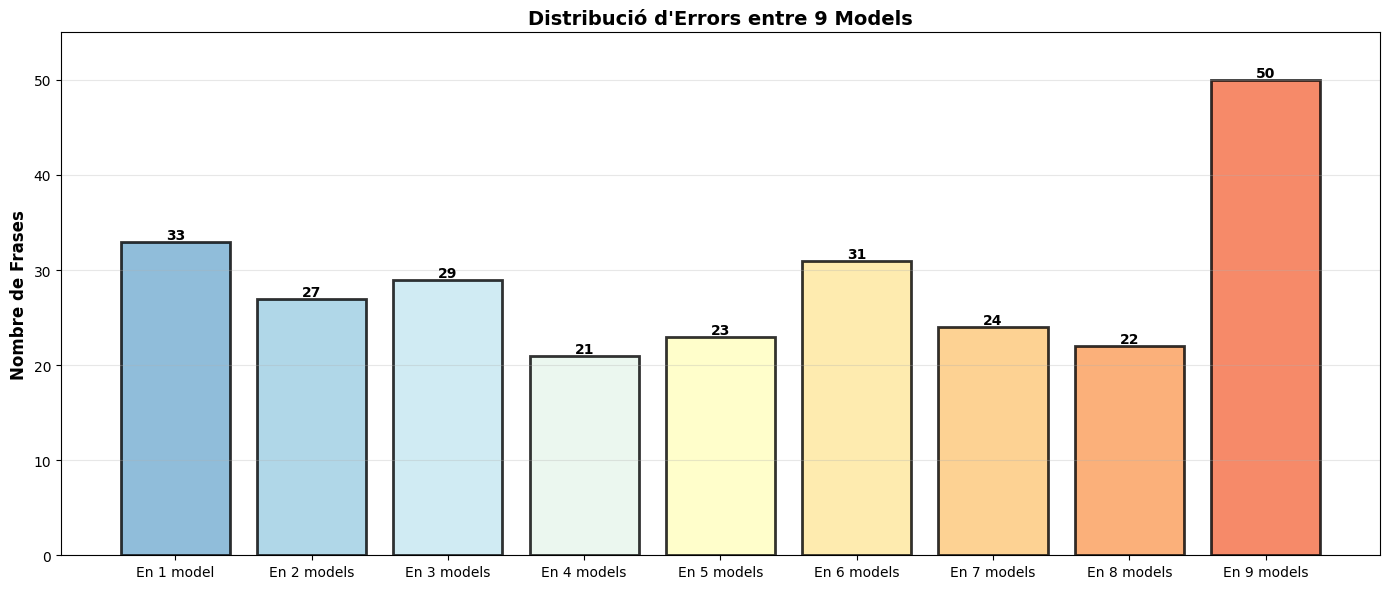

In [31]:
import matplotlib.pyplot as plt
import numpy as np

configs = list(unsupervised_results.keys())
total_models = len(configs) * len(strategies)

# Contar para cada frase en cuántos modelos falla
error_count = np.zeros(len(y_test_arr))

for config_name in configs:
    for strategy in strategies:
        errors_mask = np.array(unsupervised_results[config_name][strategy]['errors_mask'])
        error_count += errors_mask.astype(int)

# Contar cuántas frases fallan en exactamente n modelos
errors_by_count = {}
for n in range(1, total_models + 1):
    errors_by_count[n] = np.sum(error_count == n)

# Crear gràfic
fig, ax = plt.subplots(figsize=(14, 6))

categories = [f"En {n} model{'s' if n > 1 else ''}" for n in range(1, total_models + 1)]
values = [errors_by_count[n] for n in range(1, total_models + 1)]
colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, total_models))

bars = ax.bar(categories, values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

ax.set_ylabel('Nombre de Frases', fontsize=12, fontweight='bold')
ax.set_title(f'Distribució d\'Errors entre {total_models} Models', fontsize=14, fontweight='bold')
ax.set_ylim([0, max(values) + max(values)*0.1])
ax.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


##### ERRORS SITEMÀTICS (EXEMPLES MAL CLASSIFICATS EN ELS 9 MODELS)

In [33]:
from nltk.corpus import movie_reviews as mr
from sklearn.model_selection import train_test_split

# Cargar documentos originales y limpios
documents_original = []
documents_clean = []
labels_all = []

for categoria in mr.categories():
    for fileid in mr.fileids(categoria):
        raw_text = mr.raw(fileid)
        clean_text = clean_text_string(raw_text)
        
        if clean_text:
            documents_original.append(raw_text)
            documents_clean.append(clean_text)
            labels_all.append(categoria)

# Split amb el mateix random_state per alinear amb y_test_arr
X_train_orig, X_test_orig, X_train_clean, X_test_clean, y_train_split, y_test_split = train_test_split(
    documents_original, documents_clean, labels_all, 
    test_size=0.2, random_state=42
)

# Convertir y_test a array
y_test_split = np.array(y_test_split)

# Ara la funció funciona
def analizar_error(num_error):
    """
    Mostra la informació completa d'un error específic que falla en els 9 models.
    """
    
    configs = list(unsupervised_results.keys())
    
    errors_all_models = None
    for config_name in configs:
        for strategy in strategies:
            errors_mask = np.array(unsupervised_results[config_name][strategy]['errors_mask'])
            if errors_all_models is None:
                errors_all_models = errors_mask.copy()
            else:
                errors_all_models = errors_all_models & errors_mask
    
    errors_all_models = np.where(errors_all_models)[0]
    
    if num_error < 1 or num_error > len(errors_all_models):
        print(f"Error: El número ha d'estar entre 1 i {len(errors_all_models)}")
        return
    
    idx = errors_all_models[num_error - 1]
    
    actual = y_test_split[idx]
    text_original = X_test_orig[idx].replace('\n', ' ')
    text_clean = X_test_clean[idx]
    
    print(f"ERROR {num_error} (de {len(errors_all_models)} totals)")
    print(f"\nETIQUETA REAL: {actual.upper()}")
    
    print(f"\nTEXT ORIGINAL:")
    print(f"  {text_original}")
    
    print(f"\nTEXT PREPROCESSAT:")
    print(f"  {text_clean}")
    
    print(f"\nPREDICCIONS (9 MODELS):")
    print("-" * 120)
    
    for config_name in configs:
        print(f"\nConfiguració: {config_name}")
        for strategy in strategies:
            result = unsupervised_results[config_name][strategy]
            pred = result['y_pred'][idx]
            score = result['scores'][idx]
            print(f"  • Estratègia '{strategy:8s}' → Predicció: {pred:4s} | Puntuació: {score:7.4f}")

In [34]:
analizar_error(1)

ERROR 1 (de 50 totals)

ETIQUETA REAL: NEG

TEXT ORIGINAL:
  in the year 2029 , captain leo davidson ( mark wahlberg , " boogie nights " ) is training 'his' chimp pericles to pilot a pod from the usaf oberon space station .  when an electromagnetic storm is encountered and pericles' pod is lost , davidson sets out unauthorized and lands thousands of years in the future on the " planet of the apes . "  maybe if 20th century fox had set the proverbial 100 chimps in front of typewriters they would have gotten a better results than this adaptation of the pierre boulle novel by william broyles jr . ( " cast away " ) , and lawrence konner & mark d . rosenthal ( " mighty joe young " ) .  director tim burton's unique look and style are nowhere to be found in this silly , pointless remake .  davidson no sooner lands than he finds himself being swarmed by savages running in terror , whom he wisely joins .  however , he's rounded up with the lot of them by the apes which rule this plant and hande

Un dels errors observats correspon a una ressenya clarament negativa que el sistema classifica com a positiva. Aquest tipus d’error és habitual en mètodes no supervisats basats en lèxics com SentiWordNet, ja que el model calcula el sentiment sumant els scores individuals de les paraules sense tenir en compte el context global del text. En aquesta ressenya apareixen diverses paraules amb connotació positiva com better, unique, impressive o success, que contribueixen a augmentar la puntuació positiva tot i que el discurs general del text és crític. A més, la ressenya és relativament llarga i combina comentaris positius puntuals amb una valoració global negativa, fet que dificulta la classificació correcta. Aquest exemple mostra una de les limitacions principals dels mètodes lèxics: la incapacitat per captar ironia, contrastos discursius o valoracions implícites dins del context.

A més, es pot observar com en el models que tenen en compte més categories lexiques augmenta el soroll de manera significativa, degut a la presencia de paraules més neutres com els noms.

In [37]:
analizar_error(2)

ERROR 2 (de 50 totals)

ETIQUETA REAL: NEG

TEXT ORIGINAL:
  movie reviewers have an obligation to see the good , the bad , and the despicable .  i originally wrote this review for my college newspaper back in '95 , but i wanted to re-write it because not all retro reviews should be about the classics .  we need to be warned about some truly awful films , too .  this picture was so bad , it inspired the description for my 1/10 rating ( see ratings chart below ) .  the only thing saving it from a 0/10 rating is that being able to rent a movie like this is slightly less embarassing than renting a porno .  so , it does indeed have some plusses . . .  in fairness , elizabeth berkley is certainly worth seeing in the buff .  and her ability to whine and irritate us , even while nude , was appropriate in her role as selfish temptress nomi malone .  this character is not smart , not interesting , and ( deliberately ? )  far too annoying far too often .  like in 1998s " bulworth " , when the mo

## Millores model no supervisat

Tu implementación está bastante bien, pero hay 3 mejoras muy claras que pueden ayudarte a subir la accuracy y evitar algunos errores típicos en SentiWordNet.

Los cambios que vamos a introducir son:

1️. Arreglar el preprocessing de negaciones
Ahora mismo "don't" nunca aparece porque antes eliminas el ' con la regex.
Además vamos a marcar las negaciones para poder invertir el sentimiento.

2️. Detectar negación en el modelo
Si una palabra aparece después de not / no / never, invertimos el score.

3️. Normalizar el score final
Dividir el score por el número de synsets encontrados para evitar que textos largos acumulen score artificial.

### Canvis en el preprocessing

Cambios importantes:
- conservar negaciones
- convertir "don't" → "not"
- marcar palabras negadas (NOT_word)

exemple: not good movie --> NOT_good movie

Este código incorpora todo lo que hemos comentado:

- tokenización que separa contracciones
- conversión automática de n't → not
- stopwords
- lematización
- POS tagging
- negación inteligente (NOT_)
- extensión si hay adverbio


Ejemplo

Texto: I did not really like this movie

Pipeline: did not really like movie

Resultado final: NOT_really NOT_like movie

Ahora "like" queda correctamente negado, que es lo importante para sentiment.

Durant el preprocessament del text s’han aplicat diverses tècniques per millorar la representació lingüística de les opinions. En primer lloc, s’ha realitzat una normalització del text passant-lo a minúscules i eliminant caràcters no alfabètics. Posteriorment s’ha aplicat una tokenització utilitzant el tokenitzador de NLTK, que permet separar correctament les contraccions de l’anglès (per exemple didn't → did + n't), transformant posteriorment n't en la partícula de negació not. També s’han eliminat les stopwords i s’ha aplicat una lematització mitjançant WordNet per reduir les paraules a la seva forma base. A més, s’ha implementat un tractament específic de les negacions: quan apareix una paraula de negació (not, no, nor), el terme següent es marca amb el prefix NOT_ per capturar la inversió de polaritat en el sentiment. Per tal de gestionar estructures freqüents com not very good o not really interesting, s’ha utilitzat etiquetatge morfosintàctic (POS tagging) i, si després de la negació apareix un adverbi, la negació s’estén fins al següent terme rellevant. Aquest mecanisme permet capturar millor les dependències semàntiques de la negació i millorar la representació del sentiment en el model.

In [81]:

import re
import numpy as np
import nltk

from nltk.corpus import stopwords, wordnet as wn, sentiwordnet as swn
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.wsd import lesk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc, classification_report
)


In [101]:
for recurs in ["punkt", "stopwords", "wordnet", "averaged_perceptron_tagger",
               "sentiwordnet", "punkt_tab", "movie_reviews"]:
    nltk.download(recurs, quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
NEGACIONS = {"not", "no", "never", "neither", "nor"}

In [102]:
def penn_to_wn(tag: str):
    """Converteix etiquetes Penn Treebank a etiquetes POS de WordNet."""
    if tag.startswith("J"): return wn.ADJ
    if tag.startswith("V"): return wn.VERB
    if tag.startswith("N"): return wn.NOUN
    if tag.startswith("R"): return wn.ADV
    return None

WN_TAG_MAP = {
    wn.ADJ:  "ADJ",
    wn.VERB: "VERB",
    wn.NOUN: "NOUN",
    wn.ADV:  "ADV"
}

LABEL_TO_WN = {v: k for k, v in WN_TAG_MAP.items()}

In [106]:
def clean_text_string_not(text: str) -> str:
    """
    Neteja el text, lematitza amb POS correcte i marca negacions.
    Format de sortida: 'word/POS' o 'NOT_word/POS'
    Exemple: 'good/ADJ NOT_bad/ADJ run/VERB'
    """
    text = text.lower()
    text = re.sub(r"[^a-z\s']", " ", text)

    tokens = word_tokenize(text)
    tokens = ["not" if t == "n't" else t for t in tokens]
    tagged_tokens = pos_tag(tokens)

    cleaned_tokens = []
    negate = False

    for word, pos in tagged_tokens:

        if word in NEGACIONS:
            negate = True
            continue

        if word in stop_words or len(word) <= 1:
            continue

        wn_pos = penn_to_wn(pos)
        lemma = lemmatizer.lemmatize(word, pos=wn_pos if wn_pos else wn.NOUN)

        # Etiquetem el token amb el seu POS per evitar recalcular-lo després
        pos_label = WN_TAG_MAP.get(wn_pos, "OTHER")
        prefix = "NOT_" if negate else ""
        cleaned_tokens.append(f"{prefix}{lemma}/{pos_label}")

        if negate:
            negate = pos.startswith("RB")

    return " ".join(cleaned_tokens)

In [ ]:
from nltk.corpus import movie_reviews as mr

documents_not   = []
labels_all      = []

for categoria in mr.categories():
    for fileid in mr.fileids(categoria):
        raw_text   = mr.raw(fileid)
        clean_not  = clean_text_string_not(raw_text)

        if clean_not:
            documents_not.append(clean_not)
            labels_all.append(categoria)

# Un sol split — mateix random_state garanteix comparació justa entre models

X_train_not, X_test_not, \
y_train_not, y_test_not = train_test_split(
    documents_not, labels_all,
    test_size=0.2, random_state=42
)


print(f"Train: {len(X_train)} mostres | Test: {len(X_test)} mostres")

Train: 1600 mostres | Test: 400 mostres


In [109]:
def _score_synset(synset) -> float | None:
    """Retorna la puntuació de sentiment d'un synset o None si no existeix."""
    try:
        swn_synset = swn.senti_synset(synset.name())
        return swn_synset.pos_score() - swn_synset.neg_score()
    except Exception:
        return None


def sentiment_score_unsupervised_wsd_not(
    clean_text: str,
    pos_categories: list = ["ADJ"],
    strategy: str = "ignore"
) -> tuple:
    """
    Calcula la puntuació de sentiment usant Lesk + SentiWordNet.
    Rep el text en format 'word/POS' generat per clean_text_string_not.

    Estratègies:
      - 'ignore'  : usa Lesk; si no troba res, descarta la paraula
      - 'first'   : usa Lesk; si falla, agafa el primer synset de WordNet
      - 'average' : mitjana de tots els synsets de WordNet
    """
    tokens_with_pos = clean_text.split()

    # Necessitem els tokens nets (sense /POS ni NOT_) per passar context a Lesk
    context_tokens = [
        t.rsplit("/", 1)[0].replace("NOT_", "")
        for t in tokens_with_pos if "/" in t
    ]

    total_score    = 0.0
    synsets_found  = 0
    synsets_not_found = 0

    for token in tokens_with_pos:
        if "/" not in token:
            continue

        word, pos_label = token.rsplit("/", 1)

        # Filtrem per categoria POS i descartem OTHER
        if pos_label == "OTHER" or pos_label not in pos_categories:
            synsets_not_found += 1
            continue

        wn_tag = LABEL_TO_WN.get(pos_label)
        if wn_tag is None:
            synsets_not_found += 1
            continue

        negated = word.startswith("NOT_")
        if negated:
            word = word[4:]

        score = None

        if strategy in ("ignore", "first"):
            synset = lesk(context_tokens, word, pos=wn_tag)

            if synset is None and strategy == "first":
                synsets_list = wn.synsets(word, pos=wn_tag)
                synset = synsets_list[0] if synsets_list else None

            if synset:
                score = _score_synset(synset)

        elif strategy == "average":
            synsets_list = wn.synsets(word, pos=wn_tag)
            scores_list = [s for syn in synsets_list
                           if (s := _score_synset(syn)) is not None]
            if scores_list:
                score = float(np.mean(scores_list))

        if score is not None:
            total_score += -score if negated else score
            synsets_found += 1
        else:
            synsets_not_found += 1

    normalized_score = total_score / synsets_found if synsets_found > 0 else 0.0
    return normalized_score, synsets_found, synsets_not_found

In [119]:

# Combinacions de categories POS que volem avaluar
pos_configs = {
    "ADJ": ["ADJ"],
    "NOUN+ADJ+ADV": ["ADJ", "ADV"],
    "ADJ+ADV+VERB+NOUN": ["ADJ", "ADV", "VERB", "NOUN"],
}

strategies = ["ignore", "first", "average"]

In [120]:
unsupervised_results_not = {}
y_test_arr_not = np.array(y_test_not)

for config_name, pos_list in pos_configs.items():
    unsupervised_results_not[config_name] = {}

    for strategy in strategies:
        print(f"\nConfiguració: {config_name} | Estratègia: {strategy}")

        scores, found_list, not_found_list = [], [], []

        for text in X_test_not:
            score, found, not_found = sentiment_score_unsupervised_wsd_not(
                text,
                pos_categories=pos_list,
                strategy=strategy
            )
            scores.append(score)
            found_list.append(found)
            not_found_list.append(not_found)

        scores_arr = np.array(scores)

        # Comprovació de debugging: si tots els scores són 0 avisem
        non_zero = np.sum(scores_arr != 0)
        print(f"  [DEBUG] Scores no zero: {non_zero}/{len(scores_arr)}")

        # Classificació binària: positiu si score > 0
        y_pred = np.where(scores_arr > 0, "pos", "neg")

        # Mètriques d'avaluació
        accuracy  = accuracy_score(y_test_not, y_pred)
        precision = precision_score(y_test_not, y_pred, pos_label="pos", zero_division=0)
        recall    = recall_score(y_test_not, y_pred, pos_label="pos", zero_division=0)
        f1        = f1_score(y_test_not, y_pred, pos_label="pos", zero_division=0)
        cm        = confusion_matrix(y_test_not, y_pred)

        # Corba ROC
        y_test_bin  = (y_test_arr_not == "pos").astype(int)
        scores_norm = (scores_arr - scores_arr.min()) / (scores_arr.max() - scores_arr.min() + 1e-10)
        fpr, tpr, _ = roc_curve(y_test_bin, scores_norm)
        roc_auc     = auc(fpr, tpr)

        errors_mask   = y_pred != y_test_arr_not
        error_indices = np.where(errors_mask)[0]

        unsupervised_results_not[config_name][strategy] = {
            "pos_list":      pos_list,
            "scores":        scores_arr,
            "y_pred":        y_pred,
            "accuracy":      accuracy,
            "precision":     precision,
            "recall":        recall,
            "f1":            f1,
            "cm":            cm,
            "synsets_stats": {
                "found":     found_list,
                "not_found": not_found_list,
                "processed": [f + nf for f, nf in zip(found_list, not_found_list)]
            },
            "fpr":           fpr,
            "tpr":           tpr,
            "roc_auc":       roc_auc,
            "errors_mask":   errors_mask,
            "error_indices": error_indices,
            "num_errors":    int(np.sum(errors_mask))
        }

        print(f"  - Accuracy: {accuracy:.3f} | F1: {f1:.3f} | AUC: {roc_auc:.3f}")


Configuració: ADJ | Estratègia: ignore
  [DEBUG] Scores no zero: 390/400
  - Accuracy: 0.590 | F1: 0.653 | AUC: 0.677

Configuració: ADJ | Estratègia: first
  [DEBUG] Scores no zero: 396/400
  - Accuracy: 0.642 | F1: 0.690 | AUC: 0.720

Configuració: ADJ | Estratègia: average
  [DEBUG] Scores no zero: 400/400
  - Accuracy: 0.680 | F1: 0.716 | AUC: 0.731

Configuració: NOUN+ADJ+ADV | Estratègia: ignore
  [DEBUG] Scores no zero: 397/400
  - Accuracy: 0.603 | F1: 0.694 | AUC: 0.683

Configuració: NOUN+ADJ+ADV | Estratègia: first
  [DEBUG] Scores no zero: 395/400
  - Accuracy: 0.635 | F1: 0.704 | AUC: 0.720

Configuració: NOUN+ADJ+ADV | Estratègia: average
  [DEBUG] Scores no zero: 400/400
  - Accuracy: 0.632 | F1: 0.704 | AUC: 0.736

Configuració: ADJ+ADV+VERB+NOUN | Estratègia: ignore
  [DEBUG] Scores no zero: 398/400
  - Accuracy: 0.580 | F1: 0.676 | AUC: 0.697

Configuració: ADJ+ADV+VERB+NOUN | Estratègia: first
  [DEBUG] Scores no zero: 398/400
  - Accuracy: 0.625 | F1: 0.702 | AUC: 

### Model no supervisat millorat

Cambios:
- detectar NOT_
- invertir score
- normalizar resultado
- evitar recrear pos_map en cada iteración

### Comparació dels models no supervisats

TAULA RESUM: CONFIGURACIONS I ESTRATEGIES NO SUPERVISADES

     Configuració Estratègia Accuracy Precisió Recall F1-Score    AUC
              ADJ     ignore   0.5900   0.5683 0.7662   0.6525 0.6769
              ADJ      first   0.6425   0.6115 0.7910   0.6898 0.7199
              ADJ    average   0.6800   0.6466 0.8010   0.7156 0.7312
     NOUN+ADJ+ADV     ignore   0.6025   0.5660 0.8955   0.6936 0.6830
     NOUN+ADJ+ADV      first   0.6350   0.5939 0.8657   0.7045 0.7201
     NOUN+ADJ+ADV    average   0.6325   0.5912 0.8706   0.7042 0.7356
ADJ+ADV+VERB+NOUN     ignore   0.5800   0.5521 0.8706   0.6757 0.6974
ADJ+ADV+VERB+NOUN      first   0.6250   0.5842 0.8806   0.7024 0.7216
ADJ+ADV+VERB+NOUN    average   0.5900   0.5580 0.8856   0.6846 0.7362


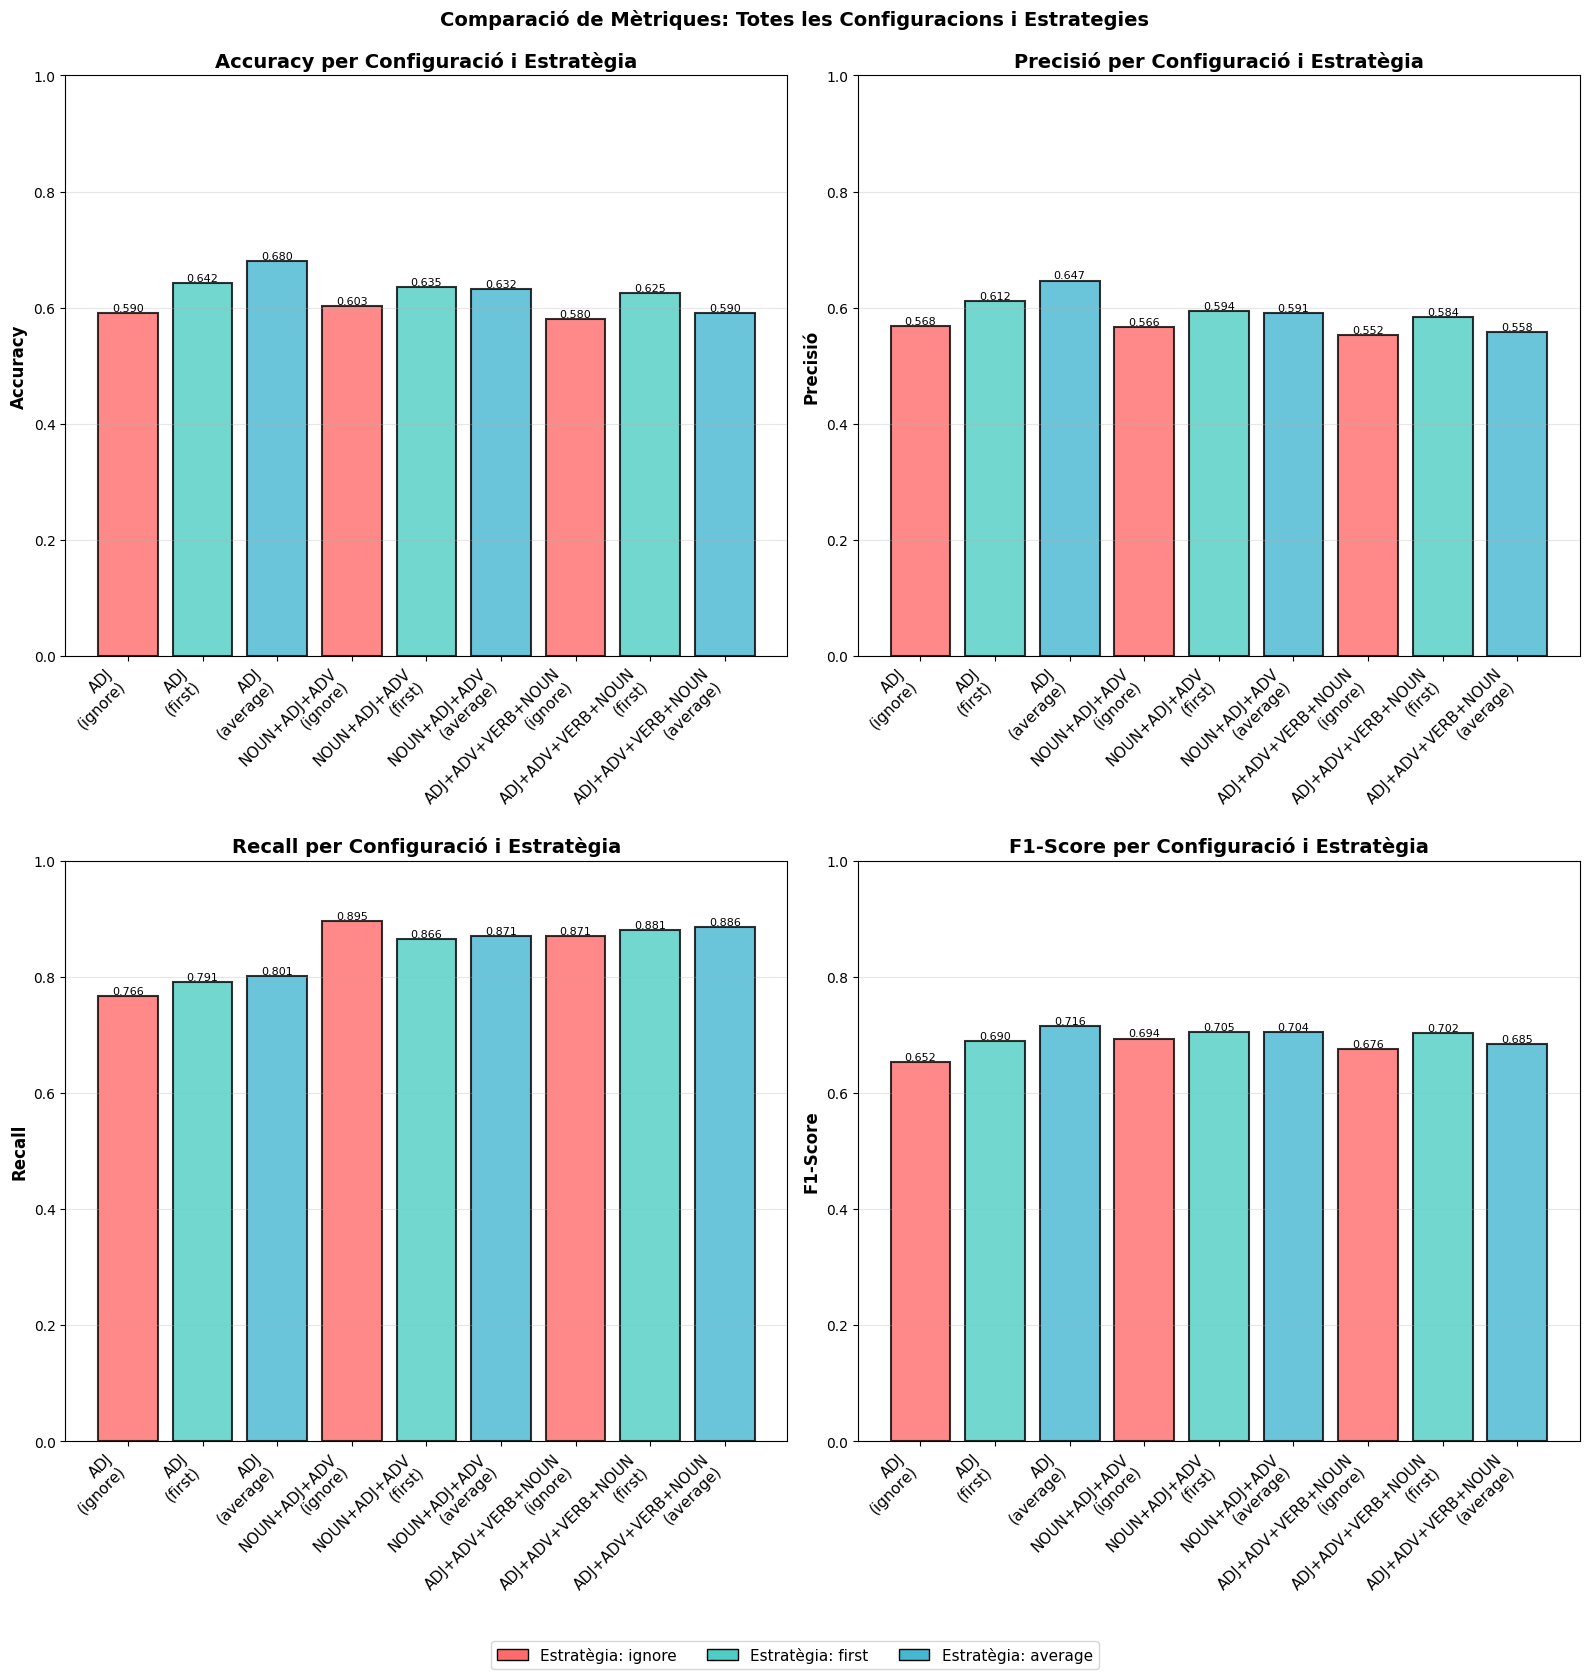

In [122]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TAULA RESUM: CONFIGURACIONS I ESTRATEGIES NO SUPERVISADES")
print("="*80)

data_rows_not = []

for config_name in pos_configs.keys():
    for strategy in strategies:
        if strategy in unsupervised_results_not[config_name]:
            result_not = unsupervised_results_not[config_name][strategy]
            data_rows_not.append({
                "Configuració": config_name,
                "Estratègia": strategy,
                "Accuracy": f"{result_not['accuracy']:.4f}",
                "Precisió": f"{result_not['precision']:.4f}",
                "Recall": f"{result_not['recall']:.4f}",
                "F1-Score": f"{result_not['f1']:.4f}",
                "AUC": f"{result_not['roc_auc']:.4f}"
            })

df_unsup_not = pd.DataFrame(data_rows_not)
print("\n" + df_unsup_not.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

metrics = ['Accuracy', 'Precisió', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    labels = [f"{row['Configuració']}\n({row['Estratègia']})" for _, row in df_unsup_not.iterrows()]
    values = [float(row[metric]) for _, row in df_unsup_not.iterrows()]

    
    colors = []
    for _, row in df_unsup_not.iterrows():
        if row['Estratègia'] == 'ignore':
            colors.append('#FF6B6B')
        elif row['Estratègia'] == 'first':
            colors.append('#4ECDC4')
        else:
            colors.append('#45B7D1')
    
    bars = ax.bar(range(len(labels)), values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} per Configuració i Estratègia', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', edgecolor='black', label='Estratègia: ignore'),
    Patch(facecolor='#4ECDC4', edgecolor='black', label='Estratègia: first'),
    Patch(facecolor='#45B7D1', edgecolor='black', label='Estratègia: average')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=11)

plt.suptitle('Comparació de Mètriques: Totes les Configuracions i Estrategies', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

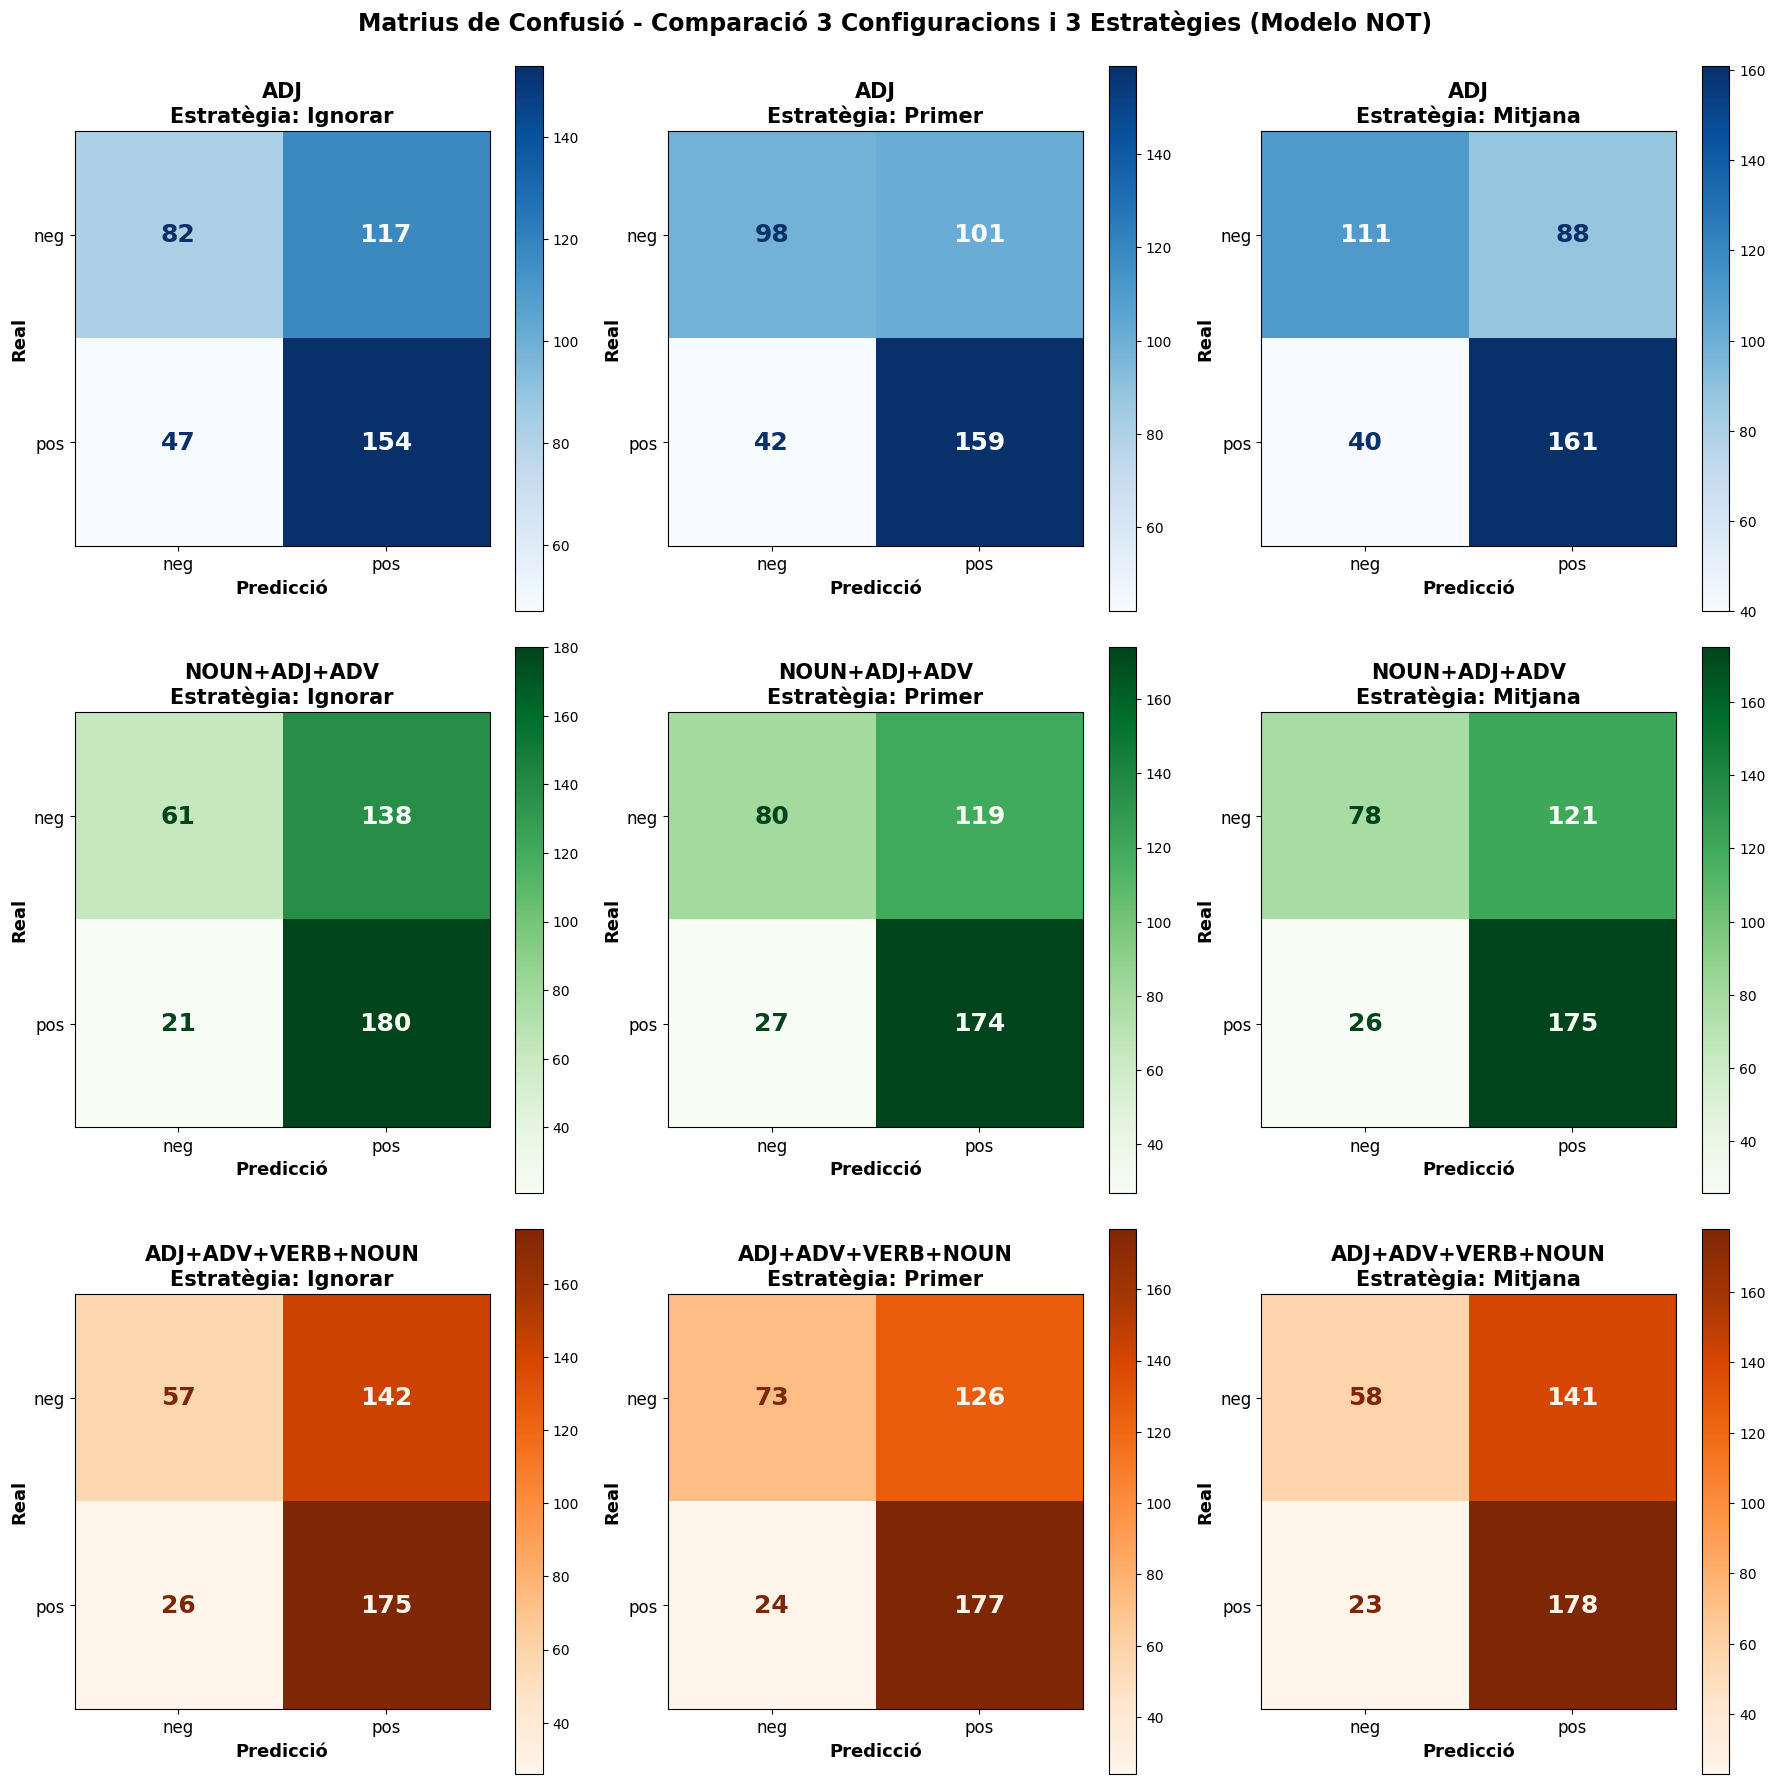

In [123]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Gráfico: 9 Matrices de Confusión en formato 3x3 (3 configuraciones × 3 estrategies)
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

configs = list(unsupervised_results_not.keys())
strategies = ["ignore", "first", "average"]
colors_list = ['Blues', 'Greens', 'Oranges']
strategy_names = {"ignore": "Ignorar", "first": "Primer", "average": "Mitjana"}

idx = 0
for config_idx, config_name in enumerate(configs):
    for strat_idx, strategy in enumerate(strategies):
        cm = unsupervised_results_not[config_name][strategy]['cm']
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"])
        disp.plot(cmap=colors_list[config_idx], ax=axes[idx], values_format='d')
        
        # Aumentar tamaño de fuente de los números en la matriz
        for text in axes[idx].texts:
            text.set_fontsize(18)
            text.set_weight('bold')
        
        # Títol amb configuració i estratègia
        title = f"{config_name}\nEstratègia: {strategy_names[strategy]}"
        axes[idx].set_title(title, fontsize=15, fontweight='bold')
        
        # Augmentar tamanys dels eixos
        axes[idx].set_xlabel("Predicció", fontsize=13, fontweight='bold')
        axes[idx].set_ylabel("Real", fontsize=13, fontweight='bold')
        axes[idx].tick_params(axis='both', labelsize=12)
        
        idx += 1

plt.suptitle('Matrius de Confusió - Comparació 3 Configuracions i 3 Estratègies (Modelo NOT)', 
             fontsize=17, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

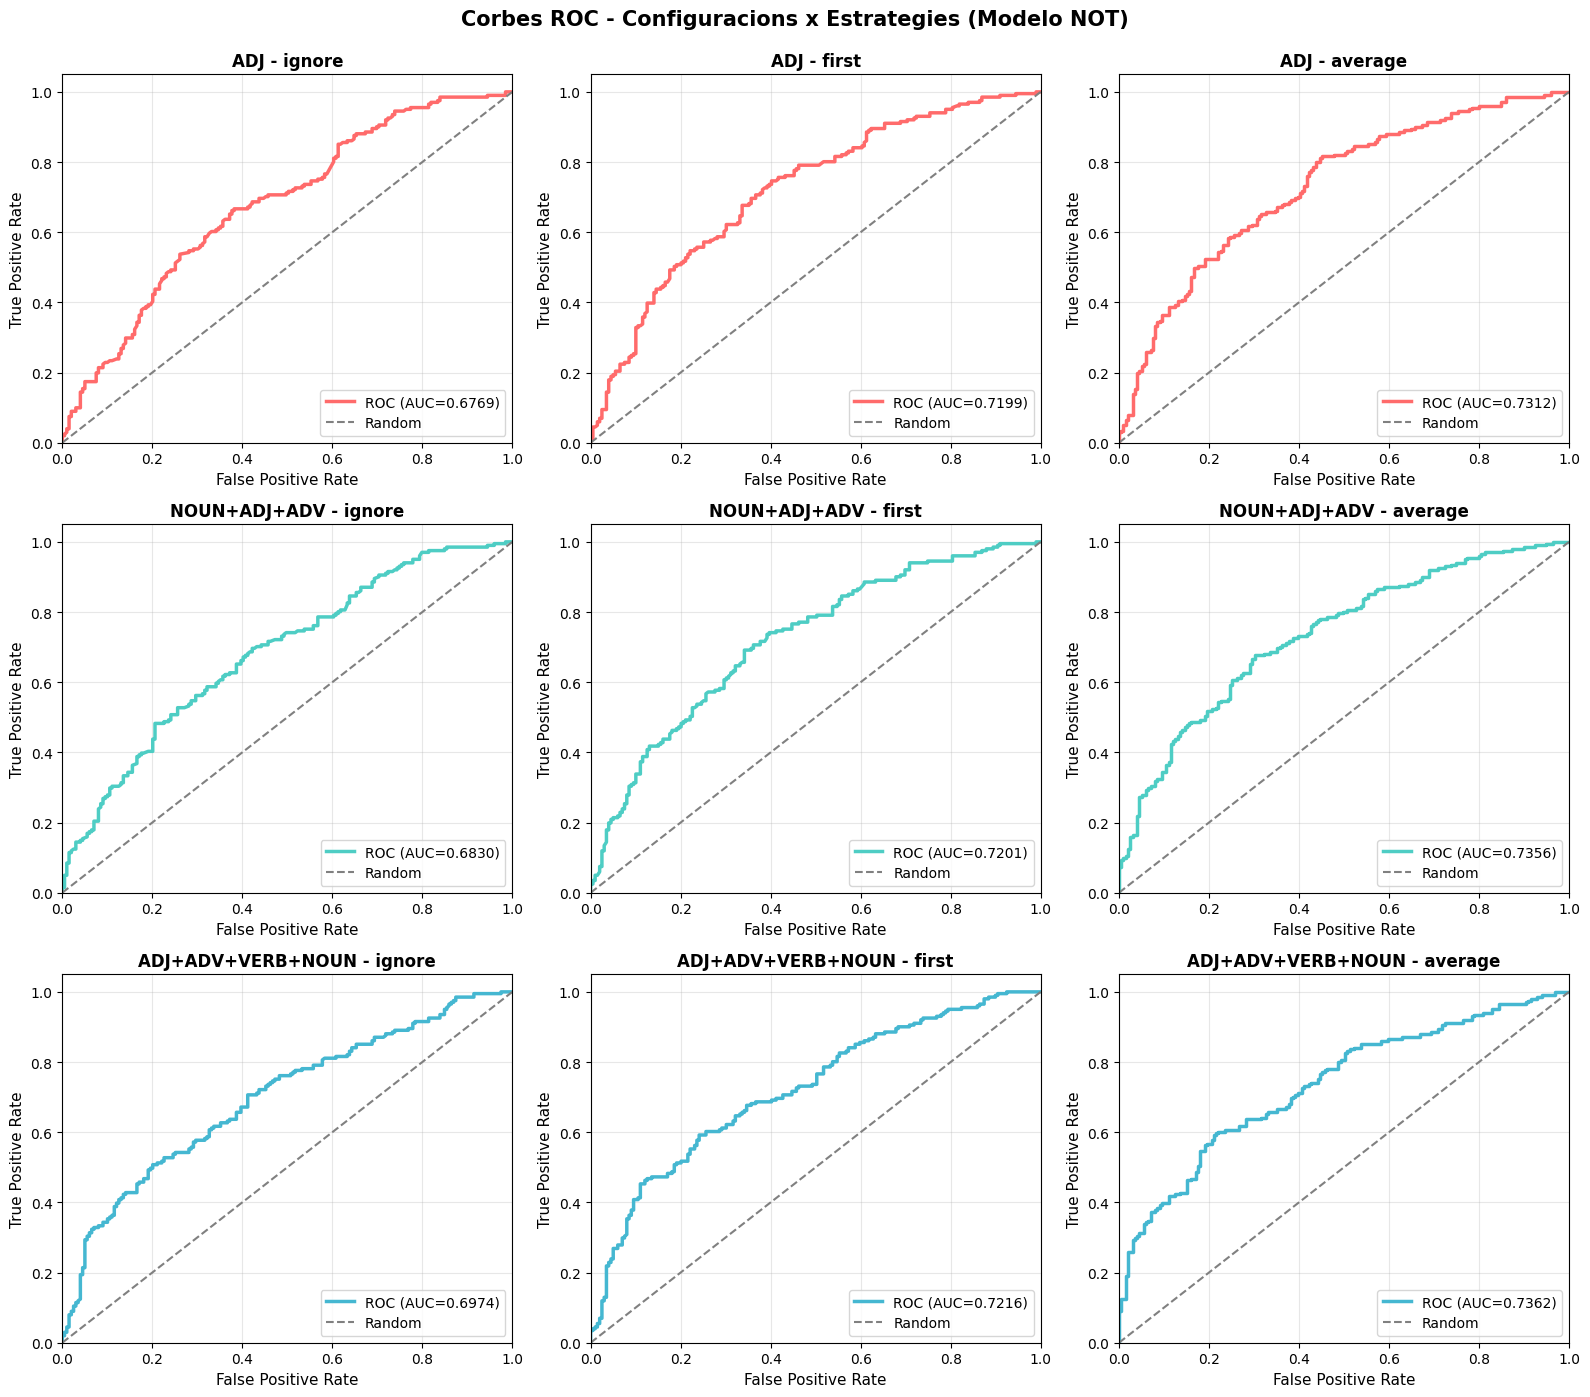

In [124]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(unsupervised_results_not), len(strategies), figsize=(16, 14))

configs = list(unsupervised_results_not.keys())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for row, config_name in enumerate(configs):
    for col, strategy in enumerate(strategies):
        result = unsupervised_results_not[config_name][strategy]
        fpr = result['fpr']
        tpr = result['tpr']
        roc_auc = result['roc_auc']
        
        ax = axes[row, col]
        
        ax.plot(fpr, tpr, color=colors[row], lw=2.5, 
                label=f'ROC (AUC={roc_auc:.4f})')
        ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random')
        
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=11)
        ax.set_ylabel('True Positive Rate', fontsize=11)
        ax.set_title(f'{config_name} - {strategy}', fontsize=12, fontweight='bold')
        ax.legend(loc='lower right', fontsize=10)
        ax.grid(alpha=0.3)

plt.suptitle('Corbes ROC - Configuracions x Estrategies (Modelo NOT)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

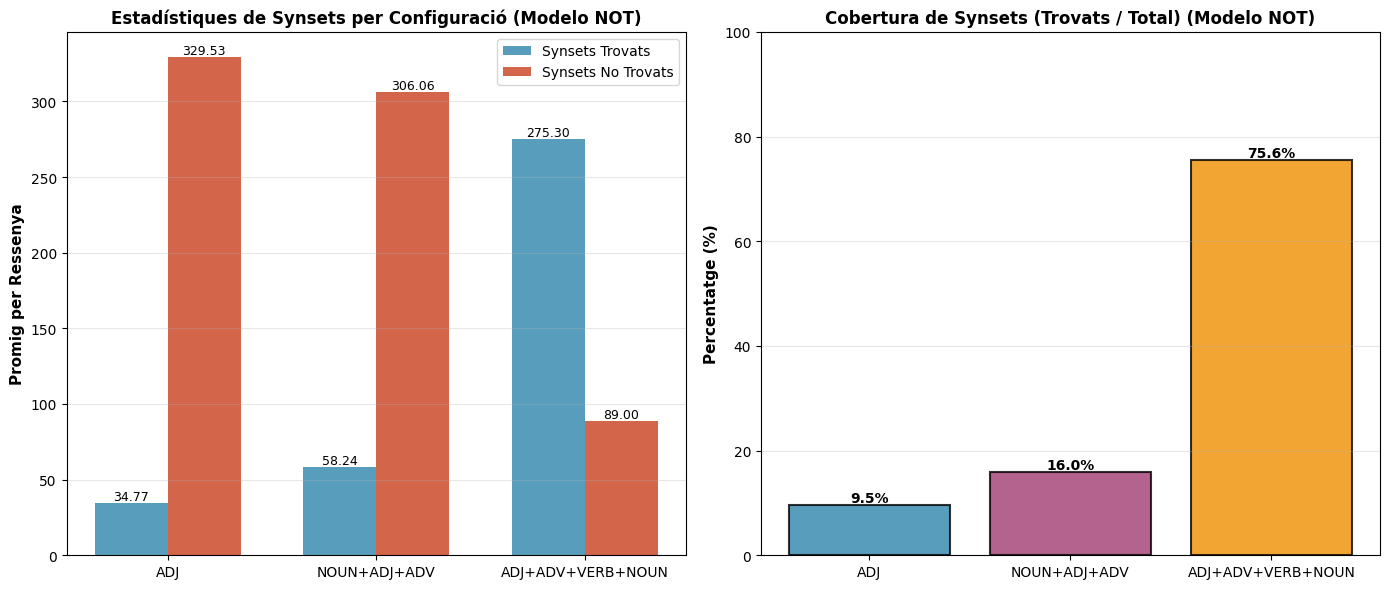


RESUM ESTADÍSTIQUES DE SYNSETS PER CONFIGURACIÓ (MODELO NOT)

     Configuració Synsets Trovats (avg) Synsets No Trovats (avg) Cobertura (%)
              ADJ                 34.77                   329.53          9.5%
     NOUN+ADJ+ADV                 58.24                   306.06         16.0%
ADJ+ADV+VERB+NOUN                275.30                    89.00         75.6%


In [125]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Extraer estadísticas para cada configuración (usar la estrategia "ignore" ya que todas tienen las mismas)
configs = list(unsupervised_results_not.keys())
avg_found_list = []
avg_not_found_list = []
coverage_pct_list = []

for config_name in configs:
    stats = unsupervised_results_not[config_name]['ignore']['synsets_stats']
    avg_found = np.mean(stats["found"])
    avg_not_found = np.mean(stats["not_found"])
    avg_processed = np.mean(stats["processed"])
    
    # Calcular cobertura (porcentaje de synsets encontrados)
    if avg_processed > 0:
        coverage_pct = (avg_found / avg_processed) * 100
    else:
        coverage_pct = 0
    
    avg_found_list.append(avg_found)
    avg_not_found_list.append(avg_not_found)
    coverage_pct_list.append(coverage_pct)

# Crear gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Synsets trovados vs No encontrados
x = np.arange(len(configs))
width = 0.35

bars1 = axes[0].bar(x - width/2, avg_found_list, width, label='Synsets Trovats', color='#2E86AB', alpha=0.8)
bars2 = axes[0].bar(x + width/2, avg_not_found_list, width, label='Synsets No Trovats', color='#C73E1D', alpha=0.8)

axes[0].set_ylabel('Promig per Ressenya', fontsize=11, fontweight='bold')
axes[0].set_title('Estadístiques de Synsets per Configuració (Modelo NOT)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(configs)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Afegir valors a les barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Porcentaje de cobertura (synsets encontrados / total procesados)
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars3 = axes[1].bar(configs, coverage_pct_list, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

axes[1].set_ylabel('Percentatge (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Cobertura de Synsets (Trovats / Total) (Modelo NOT)', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 100])
axes[1].grid(axis='y', alpha=0.3)

# Afegir valors percentuals
for bar in bars3:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Taula resum d'estadístiques
print("\nRESUM ESTADÍSTIQUES DE SYNSETS PER CONFIGURACIÓ (MODELO NOT)")
print("="*80)

summary_data = {
    "Configuració": configs,
    "Synsets Trovats (avg)": [f"{x:.2f}" for x in avg_found_list],
    "Synsets No Trovats (avg)": [f"{x:.2f}" for x in avg_not_found_list],
    "Cobertura (%)": [f"{x:.1f}%" for x in coverage_pct_list]
}

df_stats = pd.DataFrame(summary_data)
print("\n" + df_stats.to_string(index=False))

Després d’introduir el tractament de les negacions en el preprocessament i en el càlcul del sentiment, s’observa un augment notable del recall en la majoria de configuracions. Això indica que el sistema és capaç de detectar un nombre més gran de textos amb polaritat positiva o negativa correctament. No obstant això, aquest increment del recall ve acompanyat d’una lleugera disminució de la precisió, ja que el sistema tendeix a classificar més textos com a positius, generant alguns falsos positius addicionals. En conjunt, l’impacte global sobre l’accuracy és moderat, però en algunes configuracions s’observa una millora del F1-score, fet que indica un millor equilibri entre precisió i cobertura del model.

Tot i que la millora en accuracy no és molt elevada, la incorporació del tractament de negacions permet modelar millor determinades estructures lingüístiques com not good o not interesting, que d’altra manera serien interpretades incorrectament com a positives.